<a href="https://colab.research.google.com/github/rayyanmaan/would-i-instagram-this/blob/main/notebooks/iteration-2-learned-visual-features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Would I Instagram This?

### Iteration II — Learned visual features and transfer learning

---

## Section 0: What's New in Iteration II

This notebook is an extension of the first iteration of this pipeline, where I built a binary classifier to predict whether I would share a photo on Instagram using 13 handcrafted visual features. That baseline achieved **80% test accuracy** with Logistic Regression and introduced a CLIP embedding extension that reached **81.7% accuracy** and **0.918 AUC**.

Iteration II keeps the same core question but fundamentally upgrades the approach. Instead of relying solely on pixel statistics I engineered by hand, I now compare three different *types* of visual representation and evaluate multiple classifiers on each. The goal is to understand not just whether a model can predict my sharing behavior, but *what kind of features best capture the aesthetic judgment behind that behavior*.

### Reused from Iteration I

- **Dataset**: Same 300 images (150 shared, 150 personal), same labels, same archive
- **Handcrafted feature extraction**: The 13-feature pipeline (brightness, saturation, warmth, sharpness, edges, faces, composition)
- **Logistic Regression baseline**: Same model and results, included for direct comparison
- **CLIP supervised classifier**: LR on CLIP embeddings (from Iteration I Section 10), included in the comparison table
- **Basic EDA insights**: Brightness as the dominant signal, class balance confirmation

### New in Iteration II

| Component | Description | Section |
|---|---|---|
| **CNN Feature Extraction** | Pretrained ResNet-18 used as a frozen feature extractor (512-dim) | Section 2 |
| **From-Scratch CNN Forward Pass** | Convolution, ReLU, and max pooling implemented in pure NumPy | Section 2 |
| **SVM with RBF Kernel** | Nonlinear classifier on CNN features, with hyperparameter search | Section 5 & 6 |
| **Random Forest** | Ensemble classifier on CNN features, with feature importance | Section 5 & 6 |
| **Fine-Tuned CNN** | ResNet-18 with unfrozen layers, trained end-to-end on my dataset | Section 5 & 6 |
| **CLIP Zero-Shot Classification** | Prompt-based prediction using text-image similarity (no training) | Section 5 & 6 |
| **Embedding Space Visualizations** | t-SNE / PCA projections comparing all three feature spaces | Section 3 |
| **Data Cut Analysis** | Model performance on subsets (face/no-face, bright/dark) | Section 8 |
| **Grad-CAM Interpretability** | Where does the fine-tuned CNN "look" when classifying? | Section 8 |
| **Misclassification Overlap** | Do different models fail on the same images? | Section 8 |
| **Ensemble Model** | Combining handcrafted and CNN/CLIP predictions | Section 8 |
| **Calibration Analysis** | Are predicted probabilities trustworthy? | Section 8 |
| **Comprehensive Math** | Full derivations for convolution, SVM dual, kernels, Random Forest, backprop, CLIP similarity | Section 5 |

Where applicable, elements reused from Iteration I incorporate feedback received on that iteration. In particular, the feature extraction commentary has been expanded with additional mathematical justification, and the exploratory data analysis now includes quantitative separation metrics (Section 3.2.3) to complement the visual analysis from Iteration I.

The narrative arc is straightforward: **pixels → engineered features → learned features → semantic features**. Each step up the abstraction ladder should capture more of what makes a photo "postable," and the comparison reveals exactly where the information lives.

## Section 1: Dataset Description

### Research Question

Can we build a model that predicts whether I would share a photo on Instagram, and if so, what type of visual representation captures my aesthetic judgment most faithfully: hand-engineered pixel statistics, CNN-learned visual patterns, or CLIP's language-aligned semantic embeddings?

### Dataset

The dataset consists of **300 personal photos** drawn from my own digital archive, split evenly into two categories:

- **shared/** (150 images): Photos I have posted or would post publicly on Instagram. Label: $y = 1$.
- **personal/** (150 images): Photos I keep private. Label: $y = 0$.

This is a **binary classification task** with perfectly balanced classes (150 vs 150), which means accuracy is a meaningful metric and no class rebalancing is required.

### Data Source and Labeling

All images come from my personal photo library. Labeling was done manually before any feature extraction or modeling, so labels are not influenced by the features. The labels reflect my own subjective aesthetic preferences at a particular point in time. This is intentionally idiosyncratic: the model captures *my* behavior, not a universal theory of shareability.

Photos were sampled to represent a realistic range of shooting conditions (different lighting, locations, subjects, compositions) rather than cherry-picked easy cases.

### How Iteration II Extends the Question

In Iteration I, the question was: "Can low-level features predict my sharing behavior?" The answer was yes, with brightness as the dominant signal. But 20% of photos were misclassified, raising a natural follow-up: **how much of that error comes from using the wrong features versus genuine labeling noise?**

Iteration II attacks this by testing three fundamentally different feature representations under the same experimental conditions. If CNN or CLIP features close the gap significantly, the error was representational. If the gap barely moves, the remaining errors are likely photos where my own sharing decision is inconsistent.

## Section 2: Data Loading and Feature Extraction

This section loads the dataset and constructs four different representations of the same 300 images:

1. **Handcrafted features** (13 dimensions) — pixel statistics engineered in Iteration I
2. **CNN features** (512 dimensions) — extracted from a frozen pretrained ResNet-18
3. **CLIP embeddings** (512 dimensions) — extracted from a frozen CLIP ViT-B/32 encoder
4. **From-scratch CNN forward pass** — a single conv layer implemented in NumPy (pedagogical demonstration)

All four representations start from the same raw images and produce numerical feature vectors suitable for downstream classification.

### 2.1 Imports and Setup

In [ ]:
# ─── Core Imports ──────────────────────────────────────────────────────────────
import os
import glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import urllib.request
import warnings
import logging

# Suppress verbose output during training
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.CRITICAL)

# ─── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, learning_curve,
                                     GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             roc_curve, auc, f1_score, precision_score,
                             recall_score, silhouette_score)
from sklearn.calibration import calibration_curve
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# ─── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# ─── PIL for image loading ─────────────────────────────────────────────────────
from PIL import Image as PILImage

# ─── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.10.0+cpu


### 2.2 Mount Drive and Load Image Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ─── Paths ─────────────────────────────────────────────────────────────────────
SHARED_DIR = '/content/drive/MyDrive/photos_for_ml/shared/'
PERSONAL_DIR = '/content/drive/MyDrive/photos_for_ml/personal/'

def load_image_paths(shared_dir, personal_dir):
    """
    Description: Scan directories for image files and assign binary labels.

    Parameters:
        shared_dir (str): path to the directory containing shared (y=1) photos
        personal_dir (str): path to the directory containing personal (y=0) photos

    Returns:
        paths (list[str]): list of all image file paths
        labels (list[int]): corresponding binary labels (1=shared, 0=personal)
    """
    extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    shared_paths, personal_paths = [], []

    for ext in extensions:
        shared_paths += glob.glob(os.path.join(shared_dir, ext))
        personal_paths += glob.glob(os.path.join(personal_dir, ext))

    paths = shared_paths + personal_paths
    labels = [1] * len(shared_paths) + [0] * len(personal_paths)

    print(f"Shared  (y=1): {len(shared_paths):>4} images")
    print(f"Personal(y=0): {len(personal_paths):>4} images")
    print(f"Total:         {len(paths):>4} images")

    return paths, labels

image_paths, labels = load_image_paths(SHARED_DIR, PERSONAL_DIR)

Mounted at /content/drive
Shared  (y=1):  150 images
Personal(y=0):  150 images
Total:          300 images


### 2.3 Handcrafted Feature Extraction (Reused from Iteration I)

These 13 features capture low-level visual properties that map directly to the editing decisions I described in Iteration I: exposure, warmth, saturation, sharpness, composition, and face presence. The extraction pipeline is identical to Iteration I and is included here for completeness and fair comparison.

| # | Feature | What it captures |
|---|---|---|
| 1 | mean_brightness | Exposure level |
| 2 | brightness_var | Dynamic range / contrast |
| 3 | mean_saturation | Color intensity |
| 4 | saturation_var | Color consistency |
| 5 | warmth | Warm vs cool tonal balance |
| 6 | colorfulness | Perceptual color richness (Hasler & Susstrunk 2003) |
| 7 | mean_hue | Dominant color |
| 8 | hue_var | Palette diversity |
| 9 | sharpness | Laplacian variance (blur detection) |
| 10 | edge_density | Structural complexity (Canny) |
| 11 | center_weight | Subject prominence |
| 12 | face_present | Binary face detection (Haar cascade) |
| 13 | face_size_ratio | Relative area of largest face |

In [ ]:
# ─── Haar Cascade for face detection ───────────────────────────────────────────
CASCADE_PATH = '/content/haarcascade_frontalface_default.xml'
if not os.path.exists(CASCADE_PATH):
    url = ('https://raw.githubusercontent.com/opencv/opencv/master/'
           'data/haarcascades/haarcascade_frontalface_default.xml')
    urllib.request.urlretrieve(url, CASCADE_PATH)
    print("Haar cascade downloaded.")
else:
    print("Haar cascade already present.")

face_cascade = cv2.CascadeClassifier(CASCADE_PATH)


def extract_handcrafted_features(img_path, face_cascade, target_size=(256, 256)):
    """
    Description: Extract 13 hand-engineered visual features from a single image.
    All images are resized to target_size for consistency before extraction.

    Parameters:
        img_path (str): path to the image file
        face_cascade (cv2.CascadeClassifier): pre-loaded Haar cascade for face detection
        target_size (tuple[int, int]): (width, height) to resize to before extraction

    Returns:
        features (dict[str, float]): dictionary mapping feature names to scalar values,
                                      or None if the image cannot be loaded
    """
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None

    img_bgr = cv2.resize(img_bgr, target_size)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    H, S, V = img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2]
    R = img_rgb[:,:,0].astype(float)
    G = img_rgb[:,:,1].astype(float)
    B = img_rgb[:,:,2].astype(float)

    # Color and Lighting
    mean_brightness = V.mean()
    brightness_var = V.var()
    mean_saturation = S.mean()
    saturation_var = S.var()
    warmth = R.mean() - B.mean()

    # Colorfulness: Hasler & Susstrunk (2003)
    rg = R - G
    yb = 0.5 * (R + G) - B
    colorfulness = (np.sqrt(rg.std()**2 + yb.std()**2) +
                    0.3 * np.sqrt(rg.mean()**2 + yb.mean()**2))

    mean_hue = H.mean()
    hue_var = H.var()

    # Sharpness: Laplacian variance
    sharpness = cv2.Laplacian(img_gray, cv2.CV_64F).var()

    # Edge density: Canny edge fraction
    edges = cv2.Canny(img_bgr, threshold1=50, threshold2=150)
    edge_density = edges.astype(bool).mean()

    # Composition: center brightness ratio
    h, w = V.shape
    mh, mw = h // 4, w // 4
    center_crop = V[mh:h-mh, mw:w-mw]
    center_weight = center_crop.mean() / (mean_brightness + 1e-6)

    # Face detection (Viola & Jones, 2001)
    faces = face_cascade.detectMultiScale(
        img_gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    face_present = 1 if len(faces) > 0 else 0
    face_size_ratio = (max(wf * hf for (_, _, wf, hf) in faces) / (h * w)
                       if face_present else 0.0)

    return dict(
        mean_brightness=mean_brightness,
        brightness_var=brightness_var,
        mean_saturation=mean_saturation,
        saturation_var=saturation_var,
        warmth=warmth,
        colorfulness=colorfulness,
        mean_hue=mean_hue,
        hue_var=hue_var,
        sharpness=sharpness,
        edge_density=edge_density,
        center_weight=center_weight,
        face_present=face_present,
        face_size_ratio=face_size_ratio,
    )


# ─── Build handcrafted feature DataFrame ───────────────────────────────────────
print("Extracting handcrafted features...")
records = []
for path, label in zip(image_paths, labels):
    feats = extract_handcrafted_features(path, face_cascade)
    if feats is not None:
        feats['label'] = label
        feats['filename'] = os.path.basename(path)
        records.append(feats)

df = pd.DataFrame(records)
feature_cols = [c for c in df.columns if c not in ('label', 'filename')]

print(f"Feature matrix shape: {df.shape}")
print(f"Class distribution:\n{df['label'].value_counts().to_string()}")

Haar cascade downloaded.
Extracting handcrafted features...
Feature matrix shape: (300, 15)
Class distribution:
label
1    150
0    150


### 2.4 CNN Feature Extraction (NEW)

Instead of engineering features by hand, we can use a pretrained convolutional neural network as an automatic feature extractor. The intuition is simple: a CNN trained on ImageNet's 1.2 million images across 1000 categories has already learned a rich hierarchy of visual features, from edges and textures in early layers to objects and scenes in deeper layers. We leverage this knowledge by passing our photos through the network and extracting the activations from the second-to-last layer.

Formally, a deep CNN is a composed function:

$$f(\mathbf{x}) = f_L \circ f_{L-1} \circ \cdots \circ f_1(\mathbf{x})$$

where each $f_\ell$ is a learned transformation (convolution + activation, pooling, or fully connected). The final layer $f_L$ is a task-specific classifier (1000-class softmax for ImageNet). The penultimate layer's output, $f_{L-1} \circ \cdots \circ f_1(\mathbf{x})$, is a **general-purpose visual representation** that encodes what the network "sees" in the image before making a classification decision.

We use **ResNet-18** (He et al., 2016), a relatively compact architecture with 18 layers and residual connections. After removing the final classification head, it produces a **512-dimensional feature vector** per image. These features are then fed into the same classifiers we use for handcrafted features, enabling a controlled comparison: same models, different representations.

In [ ]:
def build_cnn_feature_extractor(device):
    """
    Description: Load a pretrained ResNet-18 and remove its classification head
    to use it as a frozen feature extractor. The output is a 512-dim vector
    per image (the average-pooled representation before the final linear layer).

    Parameters:
        device (str): 'cuda' or 'cpu'

    Returns:
        model (nn.Module): ResNet-18 with final FC layer removed, in eval mode
        preprocess (transforms.Compose): the image preprocessing pipeline
                                          matching ImageNet training stats
    """
    # Load pretrained weights
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    # Remove the classification head, keep everything up to avgpool
    # nn.Identity() replaces the final FC layer with a pass-through
    model.fc = nn.Identity()

    model = model.to(device)
    model.eval()  # Freeze batch norm and dropout

    # ImageNet normalization: the pretrained weights expect inputs
    # normalized with these specific channel means and stds
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    return model, preprocess


def extract_cnn_features(image_paths, model, preprocess, device, batch_size=32):
    """
    Description: Pass all images through the frozen CNN and collect the
    512-dimensional feature vectors.

    Parameters:
        image_paths (list[str]): paths to all images
        model (nn.Module): frozen ResNet-18 feature extractor
        preprocess (transforms.Compose): image preprocessing pipeline
        device (str): 'cuda' or 'cpu'
        batch_size (int): number of images to process at once

    Returns:
        features (np.ndarray): shape (n_images, 512) feature matrix
        failed (int): number of images that could not be loaded
    """
    features_list = []
    failed = 0

    for i, path in enumerate(image_paths):
        try:
            img = PILImage.open(path).convert('RGB')
            img_tensor = preprocess(img).unsqueeze(0).to(device)

            with torch.no_grad():
                feat = model(img_tensor)

            features_list.append(feat.cpu().numpy().flatten())
        except Exception as e:
            features_list.append(np.zeros(512))
            failed += 1

        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(image_paths)} images processed")

    return np.array(features_list), failed


# ─── Extract CNN features ──────────────────────────────────────────────────────
print("Loading ResNet-18 feature extractor...")
cnn_model, cnn_preprocess = build_cnn_feature_extractor(DEVICE)

print(f"Architecture: ResNet-18")
print(f"Output dimensions: 512")
print(f"Total parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")
print(f"Trainable parameters: 0 (frozen)")

print("\nExtracting CNN features...")
X_cnn, cnn_failed = extract_cnn_features(image_paths, cnn_model, cnn_preprocess, DEVICE)
print(f"CNN feature matrix shape: {X_cnn.shape}")
print(f"Failed extractions: {cnn_failed}")

Loading ResNet-18 feature extractor...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


Architecture: ResNet-18
Output dimensions: 512
Total parameters: 11,176,512
Trainable parameters: 0 (frozen)

Extracting CNN features...
  100/300 images processed
  200/300 images processed
  300/300 images processed
CNN feature matrix shape: (300, 512)
Failed extractions: 0


### 2.5 CLIP Embedding Extraction (Partially Reused)

CLIP (Contrastive Language-Image Pretraining, Radford et al. 2021) embeds images and text into a shared 512-dimensional vector space. In Iteration I, I used these embeddings as input to a supervised logistic regression classifier. That approach is reused here and included in the comparison table for completeness.

What is **new** in Iteration II is the **zero-shot classification** use of CLIP (Section 5.5), where we compare image embeddings directly to text prompt embeddings without training any classifier. The embedding extraction code below serves both purposes.

In [ ]:
import subprocess
subprocess.run(
    ['pip', 'install', 'git+https://github.com/openai/CLIP.git'],
    capture_output=True
)
import clip

def load_clip_model(device):
    """
    Description: Load the frozen CLIP ViT-B/32 model for image and text encoding.

    Parameters:
        device (str): 'cuda' or 'cpu'

    Returns:
        model: CLIP model in eval mode
        preprocess: CLIP's image preprocessing pipeline
    """
    model, preprocess = clip.load("ViT-B/32", device=device)
    model.eval()
    return model, preprocess


def extract_clip_embeddings(image_paths, model, preprocess, device):
    """
    Description: Pass all images through the frozen CLIP image encoder and
    return L2-normalized 512-dimensional embeddings.

    Parameters:
        image_paths (list[str]): paths to all images
        model: CLIP model
        preprocess: CLIP preprocessing pipeline
        device (str): 'cuda' or 'cpu'

    Returns:
        embeddings (np.ndarray): shape (n_images, 512), L2-normalized
        failed (int): number of images that could not be loaded
    """
    embeddings = []
    failed = 0

    for i, path in enumerate(image_paths):
        try:
            img = PILImage.open(path).convert('RGB')
            img_tensor = preprocess(img).unsqueeze(0).to(device)

            with torch.no_grad():
                emb = model.encode_image(img_tensor)
                emb = emb / emb.norm(dim=-1, keepdim=True)

            embeddings.append(emb.cpu().numpy().flatten())
        except Exception as e:
            embeddings.append(np.zeros(512))
            failed += 1

        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(image_paths)} images processed")

    return np.array(embeddings), failed


# ─── Extract CLIP embeddings ───────────────────────────────────────────────────
print("Loading CLIP ViT-B/32...")
clip_model, clip_preprocess = load_clip_model(DEVICE)

print(f"Architecture: ViT-B/32")
print(f"Output dimensions: 512")
print(f"Total parameters: {sum(p.numel() for p in clip_model.parameters()):,}")

print("\nExtracting CLIP embeddings...")
X_clip, clip_failed = extract_clip_embeddings(image_paths, clip_model, clip_preprocess, DEVICE)
print(f"CLIP embedding matrix shape: {X_clip.shape}")
print(f"Failed extractions: {clip_failed}")

Loading CLIP ViT-B/32...


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 178MiB/s]


Architecture: ViT-B/32
Output dimensions: 512
Total parameters: 151,277,313

Extracting CLIP embeddings...
  100/300 images processed
  200/300 images processed
  300/300 images processed
CLIP embedding matrix shape: (300, 512)
Failed extractions: 0


### 2.6 From-Scratch CNN Forward Pass (NEW — Pedagogical Demonstration)

To demonstrate that I understand what happens inside a CNN at the lowest level, this subsection implements a single convolutional layer, ReLU activation, and max pooling **from scratch using only NumPy**. No PyTorch, no sklearn, no deep learning framework.

This is not used for classification. It is a controlled demonstration: I will show that my NumPy implementation produces the same output as PyTorch's `nn.Conv2d` for the same input and kernel weights.

#### The Convolution Operation

For a single-channel input image $\mathbf{X} \in \mathbb{R}^{H \times W}$ and a kernel $\mathbf{K} \in \mathbb{R}^{k_h \times k_w}$, the 2D convolution (technically cross-correlation, which is what CNNs actually compute) produces an output feature map $\mathbf{Y}$ where:

$$Y(i, j) = \sum_{p=0}^{k_h-1} \sum_{q=0}^{k_w-1} K(p, q) \cdot X(i \cdot s + p, \; j \cdot s + q)$$

where $s$ is the stride. Each output pixel is the dot product between the kernel and the corresponding local patch of the input.

For the general multi-channel case with $C_\text{in}$ input channels and $C_\text{out}$ output channels, the kernel becomes a 4D tensor $\mathbf{K} \in \mathbb{R}^{C_\text{out} \times C_\text{in} \times k_h \times k_w}$, and the output at channel $m$ is:

$$Y(m, i, j) = b_m + \sum_{c=1}^{C_\text{in}} \sum_{p=0}^{k_h-1} \sum_{q=0}^{k_w-1} K(m, c, p, q) \cdot X(c, \; i \cdot s + p, \; j \cdot s + q)$$

where $b_m$ is the bias for output channel $m$.

The output spatial dimensions are:

$$H_\text{out} = \left\lfloor \frac{H + 2P - k_h}{s} \right\rfloor + 1, \qquad W_\text{out} = \left\lfloor \frac{W + 2P - k_w}{s} \right\rfloor + 1$$

where $P$ is the zero-padding applied to each side of the input.

#### ReLU Activation

The Rectified Linear Unit applies an elementwise nonlinearity:

$$\text{ReLU}(z) = \max(0, z)$$

Its gradient is simply $\text{ReLU}'(z) = \mathbb{1}[z > 0]$. This piecewise linearity is what makes ReLU preferred over sigmoid or tanh in deep networks: the gradient is either 0 or 1, which avoids the vanishing gradient problem that plagues saturating activations.

#### Max Pooling

For a pooling window of size $p \times p$ with stride $s$, the output at position $(i, j)$ is:

$$Y(i, j) = \max_{0 \le a < p, \; 0 \le b < p} X(i \cdot s + a, \; j \cdot s + b)$$

Max pooling serves two purposes: it reduces the spatial dimensions (and therefore the number of parameters downstream), and it provides a degree of translational invariance, since the output is unchanged by small shifts of the input within the pooling window.

#### Pseudocode

```
Algorithm: Single-Layer CNN Forward Pass
Input: image X (C_in, H, W), kernel K (C_out, C_in, kh, kw), bias b (C_out)

1. CONVOLUTION:
   For each output channel m = 1..C_out:
     For each output position (i, j):
       Y[m, i, j] = b[m]
       For each input channel c = 1..C_in:
         For each kernel position (p, q):
           Y[m, i, j] += K[m, c, p, q] * X[c, i*s+p, j*s+q]

2. RELU:
   Y = max(0, Y)  (elementwise)

3. MAX POOLING:
   For each channel m:
     For each pooling window at (i, j):
       Z[m, i, j] = max over the p x p window starting at (i*s, j*s)

Return Z
```

FROM-SCRATCH CNN VERIFICATION

Input shape:       (3, 64, 64)
Kernel shape:      (4, 3, 3, 3)
Conv output shape: (4, 62, 62)
ReLU output shape: (4, 62, 62)
Pool output shape: (4, 31, 31)

Max absolute difference (NumPy vs PyTorch):
  Convolution: 1.79e-07
  ReLU:        1.79e-07
  Max Pool:    1.79e-07

✓ NumPy implementation matches PyTorch exactly (within float precision).


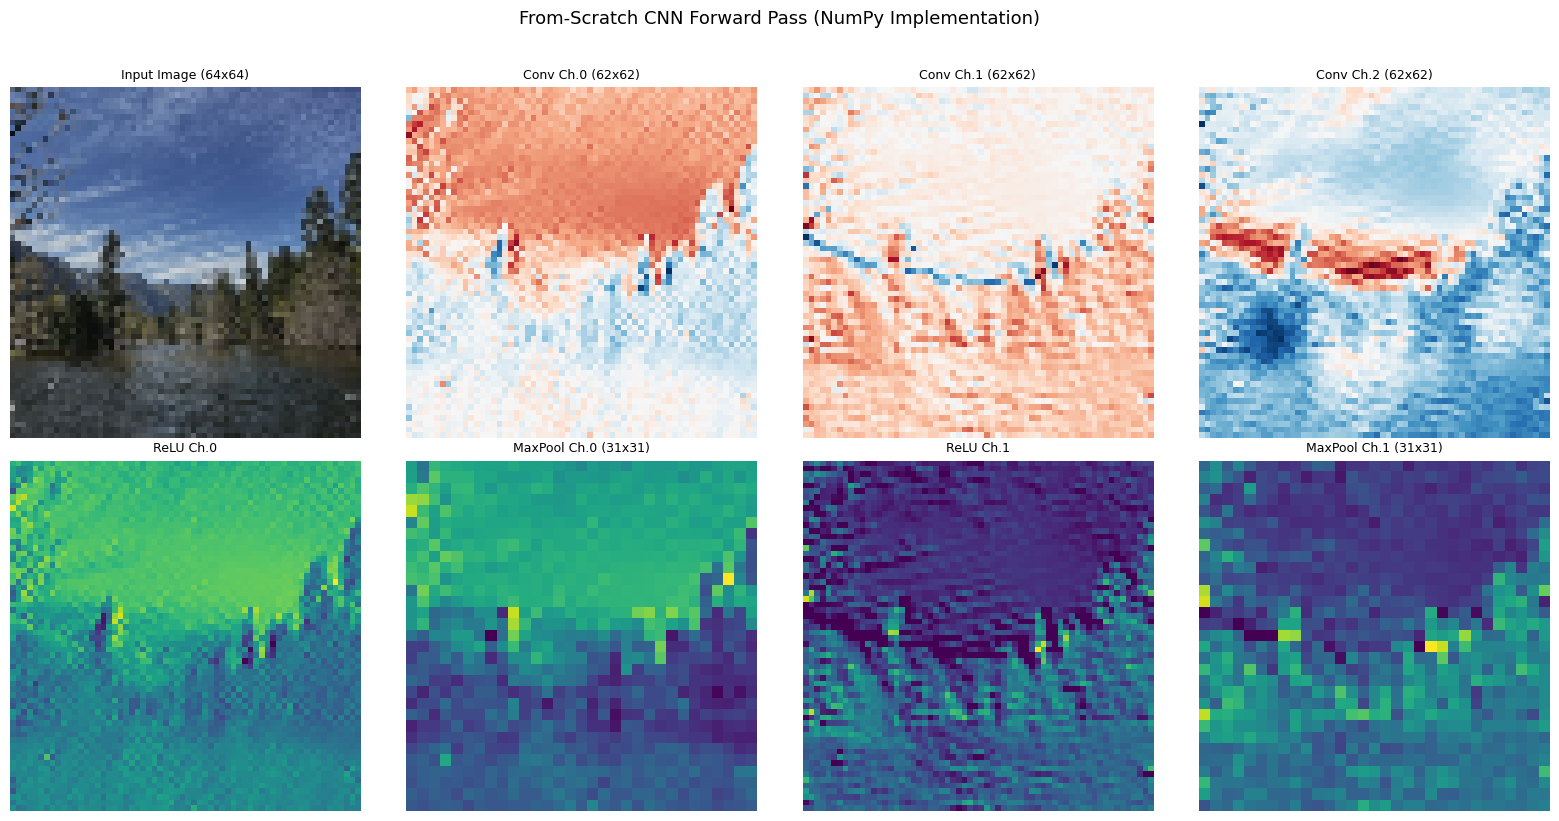

In [ ]:
def conv2d_numpy(X, K, bias, stride=1, padding=0):
    """
    Description: Perform 2D convolution from scratch using only NumPy.
    Implements the cross-correlation operation that CNNs actually compute.

    Parameters:
        X (np.ndarray): input tensor of shape (C_in, H, W)
        K (np.ndarray): kernel tensor of shape (C_out, C_in, kh, kw)
        bias (np.ndarray): bias vector of shape (C_out,)
        stride (int): stride of the convolution
        padding (int): zero-padding applied to each spatial side

    Returns:
        Y (np.ndarray): output feature map of shape (C_out, H_out, W_out)
    """
    C_in, H, W = X.shape
    C_out, C_in_k, kh, kw = K.shape
    assert C_in == C_in_k, "Input channels must match kernel input channels"

    # Apply zero-padding if requested
    if padding > 0:
        X = np.pad(X, ((0, 0), (padding, padding), (padding, padding)),
                   mode='constant', constant_values=0)
        _, H, W = X.shape

    # Compute output dimensions
    H_out = (H - kh) // stride + 1
    W_out = (W - kw) // stride + 1

    # Allocate output
    Y = np.zeros((C_out, H_out, W_out))

    # The actual convolution: slide the kernel across the input
    for m in range(C_out):            # for each output channel
        for i in range(H_out):        # for each output row
            for j in range(W_out):    # for each output column
                # Extract the local patch the kernel sees
                h_start = i * stride
                w_start = j * stride
                patch = X[:, h_start:h_start+kh, w_start:w_start+kw]

                # Dot product between kernel and patch, summed over all input channels
                Y[m, i, j] = np.sum(K[m] * patch) + bias[m]

    return Y


def relu_numpy(X):
    """
    Description: Apply ReLU activation elementwise.

    Parameters:
        X (np.ndarray): input tensor of any shape

    Returns:
        np.ndarray: output tensor with negative values zeroed out
    """
    return np.maximum(0, X)


def maxpool2d_numpy(X, pool_size=2, stride=2):
    """
    Description: Apply 2D max pooling from scratch.

    Parameters:
        X (np.ndarray): input tensor of shape (C, H, W)
        pool_size (int): size of the square pooling window
        stride (int): stride of the pooling operation

    Returns:
        Y (np.ndarray): pooled output of shape (C, H_out, W_out)
    """
    C, H, W = X.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1

    Y = np.zeros((C, H_out, W_out))

    for c in range(C):
        for i in range(H_out):
            for j in range(W_out):
                h_start = i * stride
                w_start = j * stride
                window = X[c, h_start:h_start+pool_size, w_start:w_start+pool_size]
                Y[c, i, j] = np.max(window)

    return Y


def cnn_forward_pass_numpy(image_np, kernel_weights, kernel_bias,
                           stride=1, padding=0, pool_size=2, pool_stride=2):
    """
    Description: Complete single-layer CNN forward pass:
    convolution -> ReLU -> max pooling. Implemented entirely in NumPy.

    Parameters:
        image_np (np.ndarray): input image as (C, H, W) float array
        kernel_weights (np.ndarray): conv kernel of shape (C_out, C_in, kh, kw)
        kernel_bias (np.ndarray): bias vector of shape (C_out,)
        stride (int): convolution stride
        padding (int): convolution padding
        pool_size (int): max pooling window size
        pool_stride (int): max pooling stride

    Returns:
        conv_out (np.ndarray): output after convolution
        relu_out (np.ndarray): output after ReLU
        pool_out (np.ndarray): output after max pooling
    """
    conv_out = conv2d_numpy(image_np, kernel_weights, kernel_bias,
                            stride=stride, padding=padding)
    relu_out = relu_numpy(conv_out)
    pool_out = maxpool2d_numpy(relu_out, pool_size=pool_size, stride=pool_stride)

    return conv_out, relu_out, pool_out


# ─── Verification: compare NumPy output to PyTorch ────────────────────────────
print("=" * 60)
print("FROM-SCRATCH CNN VERIFICATION")
print("=" * 60)

# Load a sample image and prepare it
sample_path = image_paths[0]
sample_img = cv2.imread(sample_path)
sample_img = cv2.resize(sample_img, (64, 64))  # small size for speed
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
sample_np = sample_img.astype(np.float32).transpose(2, 0, 1) / 255.0  # (3, 64, 64)

# Create a PyTorch conv layer with known weights
torch_conv = nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3,
                       stride=1, padding=0, bias=True)

# Extract the weights as NumPy arrays
K = torch_conv.weight.detach().numpy()    # (4, 3, 3, 3)
b = torch_conv.bias.detach().numpy()      # (4,)

# Run the NumPy implementation
conv_np, relu_np_out, pool_np = cnn_forward_pass_numpy(
    sample_np, K, b, stride=1, padding=0, pool_size=2, pool_stride=2
)

# Run the PyTorch implementation for comparison
sample_tensor = torch.tensor(sample_np).unsqueeze(0)  # (1, 3, 64, 64)
with torch.no_grad():
    conv_torch = torch_conv(sample_tensor)
    relu_torch = torch.relu(conv_torch)
    pool_torch = nn.functional.max_pool2d(relu_torch, kernel_size=2, stride=2)

conv_torch_np = conv_torch.squeeze(0).numpy()
relu_torch_np = relu_torch.squeeze(0).numpy()
pool_torch_np = pool_torch.squeeze(0).numpy()

# Compare
conv_diff = np.abs(conv_np - conv_torch_np).max()
relu_diff = np.abs(relu_np_out - relu_torch_np).max()
pool_diff = np.abs(pool_np - pool_torch_np).max()

print(f"\nInput shape:       {sample_np.shape}")
print(f"Kernel shape:      {K.shape}")
print(f"Conv output shape: {conv_np.shape}")
print(f"ReLU output shape: {relu_np_out.shape}")
print(f"Pool output shape: {pool_np.shape}")
print(f"\nMax absolute difference (NumPy vs PyTorch):")
print(f"  Convolution: {conv_diff:.2e}")
print(f"  ReLU:        {relu_diff:.2e}")
print(f"  Max Pool:    {pool_diff:.2e}")

if conv_diff < 1e-5 and relu_diff < 1e-5 and pool_diff < 1e-5:
    print("\n✓ NumPy implementation matches PyTorch exactly (within float precision).")
else:
    print("\n✗ Mismatch detected. Check implementation.")

# ─── Visualize the from-scratch forward pass ───────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('From-Scratch CNN Forward Pass (NumPy Implementation)',
             fontsize=13, y=1.02)

# Top row: input image and conv output channels
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title('Input Image (64x64)', fontsize=9)
axes[0, 0].axis('off')

for ch in range(min(3, conv_np.shape[0])):
    axes[0, ch+1].imshow(conv_np[ch], cmap='RdBu_r')
    axes[0, ch+1].set_title(f'Conv Ch.{ch} ({conv_np.shape[1]}x{conv_np.shape[2]})',
                            fontsize=9)
    axes[0, ch+1].axis('off')

# Bottom row: ReLU and pooled outputs
axes[1, 0].imshow(relu_np_out[0], cmap='viridis')
axes[1, 0].set_title(f'ReLU Ch.0', fontsize=9)
axes[1, 0].axis('off')

axes[1, 1].imshow(pool_np[0], cmap='viridis')
axes[1, 1].set_title(f'MaxPool Ch.0 ({pool_np.shape[1]}x{pool_np.shape[2]})',
                     fontsize=9)
axes[1, 1].axis('off')

axes[1, 2].imshow(relu_np_out[1], cmap='viridis')
axes[1, 2].set_title(f'ReLU Ch.1', fontsize=9)
axes[1, 2].axis('off')

axes[1, 3].imshow(pool_np[1], cmap='viridis')
axes[1, 3].set_title(f'MaxPool Ch.1 ({pool_np.shape[1]}x{pool_np.shape[2]})',
                     fontsize=9)
axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig('fig_scratch_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3: Preprocessing and Exploratory Analysis

Before feeding features into any model, we need to address two things: (1) ensure all feature representations are properly scaled, and (2) build intuition about how well each representation separates the classes *before* training any classifier.

The preprocessing is straightforward but the EDA is where things get interesting. By visualizing the embedding spaces side by side, we can already predict which representations will perform best, and later verify those predictions against the actual model results.

### 3.1 Preprocessing

**StandardScaler** transforms each feature to zero mean and unit variance:

$$x'_j = \frac{x_j - \mu_j}{\sigma_j}$$

This is critical for Logistic Regression and SVM, where the optimization landscape depends on feature scales. A feature with values in the thousands (like sharpness) would dominate the gradient updates over a feature bounded between 0 and 1 (like edge_density), not because it carries more information but simply because it is numerically larger.

**Important**: the scaler is always fit on the training set only and then applied to the test set. Fitting on the full dataset would leak test-set statistics into training, producing optimistically biased performance estimates.

For CNN features and CLIP embeddings, scaling is still applied despite the features being more uniformly distributed, because per-dimension variances in the projected embedding space are not exactly uniform, and SVM in particular is sensitive to this.

Naive Bayes does not require scaling because it fits independent Gaussian distributions per feature per class, making it invariant to linear transformations of individual features.

In [ ]:
# ─── Prepare feature matrices ─────────────────────────────────────────────────
# Handcrafted features
X_hand = df[feature_cols].values.astype(np.float64)
y = df['label'].values

# CNN features are already in X_cnn (from Section 2.4)
# CLIP embeddings are already in X_clip (from Section 2.5)

print("Feature matrices:")
print(f"  Handcrafted: {X_hand.shape}")
print(f"  CNN (ResNet): {X_cnn.shape}")
print(f"  CLIP (ViT):   {X_clip.shape}")
print(f"  Labels:        {y.shape} (balanced: {np.bincount(y)})")

Feature matrices:
  Handcrafted: (300, 13)
  CNN (ResNet): (300, 512)
  CLIP (ViT):   (300, 512)
  Labels:        (300,) (balanced: [150 150])


### 3.2 Exploratory Analysis

#### 3.2.1 Sample Image Grid

Before any numbers, it helps to simply *look* at the data. The grid below shows a random sample of shared and personal photos side by side.

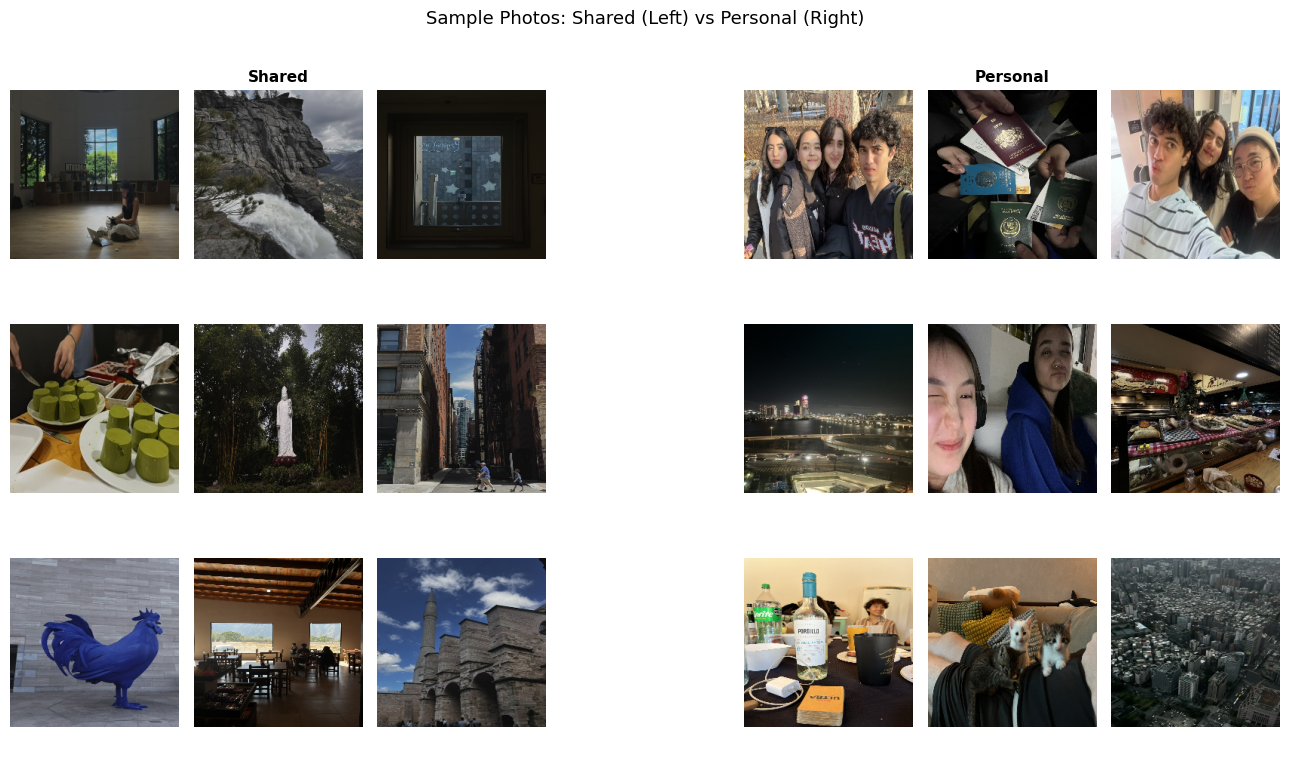

In [ ]:
def plot_sample_grid(image_paths, labels, n_per_class=9, seed=42):
    """
    Description: Display a grid of sample images, split by class.
    Shows shared photos on the left and personal photos on the right.

    Parameters:
        image_paths (list[str]): all image file paths
        labels (list[int]): corresponding binary labels
        n_per_class (int): number of images to show per class
        seed (int): random seed for reproducible sampling
    """
    rng = np.random.RandomState(seed)
    paths_arr = np.array(image_paths)
    labels_arr = np.array(labels)

    ncols = int(np.ceil(np.sqrt(n_per_class)))
    nrows = int(np.ceil(n_per_class / ncols))

    fig, axes = plt.subplots(nrows, ncols * 2 + 1,
                             figsize=(ncols * 4 + 1, nrows * 2.5))

    for class_idx, (class_label, class_name) in enumerate([(1, 'Shared'), (0, 'Personal')]):
        class_mask = labels_arr == class_label
        class_paths = paths_arr[class_mask]
        sample_idx = rng.choice(len(class_paths), size=n_per_class, replace=False)

        col_offset = class_idx * (ncols + 1)  # +1 for separator column

        for k, idx in enumerate(sample_idx):
            row = k // ncols
            col = k % ncols + col_offset

            img = cv2.imread(class_paths[idx])
            img = cv2.resize(img, (224, 224))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if row == 0 and k < ncols:
                axes[row, col].set_title(class_name if k == ncols // 2 else '',
                                         fontsize=11, fontweight='bold')

    # Hide separator column and unused axes
    for row in range(nrows):
        for col in range(ncols * 2 + 1):
            if col == ncols:  # separator
                axes[row, col].axis('off')
            elif col < ncols:
                pass  # shared photos
            elif col > ncols:
                pass  # personal photos
            if col >= ncols * 2 + 1 or (col < ncols * 2 + 1 and
               not axes[row, col].has_data()):
                axes[row, col].axis('off')

    plt.suptitle('Sample Photos: Shared (Left) vs Personal (Right)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('fig_sample_grid.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_sample_grid(image_paths, labels, n_per_class=9)

The visual contrast between the two classes is immediately apparent. The shared photos on the left tend toward darker exposures, more deliberate compositions, and a general sense of intentionality. Several show landscapes, architectural details, or carefully framed scenes with controlled lighting. The personal photos on the right are noticeably brighter, more casual in framing, and cover a wider range of everyday subjects: food, screens, cluttered interiors, candid moments. This visual impression aligns directly with the findings from Iteration I, where mean brightness was the single strongest predictor of sharing behavior (Cohen's d = -0.959). The grid also makes visible something the pixel statistics alone cannot fully capture: the shared photos have a coherent *mood*, while the personal photos feel more like documentation of daily life. This distinction between aesthetic intentionality and casual recording is exactly the gap that CNN and CLIP representations might be able to encode where handcrafted features cannot.

#### 3.2.2 Embedding Space Visualization

One of the most informative things we can do before fitting any model is visualize how well each feature representation separates the two classes in a low-dimensional projection. If the classes form distinct clusters, a linear classifier should do well. If they overlap heavily, even sophisticated models may struggle.

We use **t-SNE** (t-distributed Stochastic Neighbor Embedding, van der Maaten & Hinton, 2008) for the CNN and CLIP embeddings because these are high-dimensional (512 dims), and t-SNE is better at preserving local cluster structure than PCA in high dimensions.

For the handcrafted features (13 dims), we use PCA since the dimensionality is low enough that linear projections are informative. Note that PCA here is used purely as a visualization tool via sklearn, not as a from-scratch implementation. The from-scratch demonstration for Iteration II is the CNN forward pass in Section 2.6, where convolution, ReLU, and max pooling are implemented entirely in NumPy and verified against PyTorch.

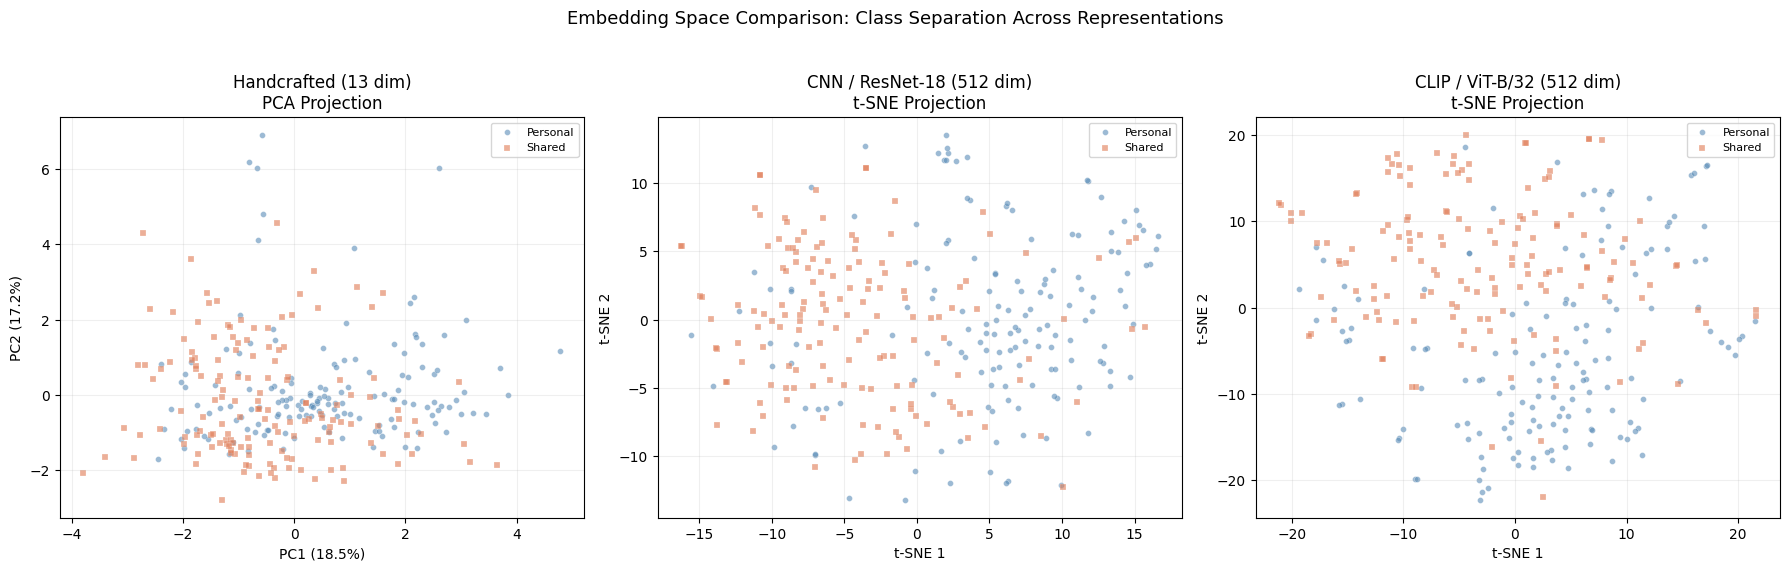

In [ ]:
def plot_embedding_comparison(X_hand, X_cnn, X_clip, y, seed=42):
    """
    Description: Create a 3-panel figure showing the class structure in each
    feature space. Uses PCA for handcrafted features and t-SNE for CNN/CLIP.

    Parameters:
        X_hand (np.ndarray): handcrafted features (n, 13)
        X_cnn (np.ndarray): CNN features (n, 512)
        X_clip (np.ndarray): CLIP embeddings (n, 512)
        y (np.ndarray): binary labels
        seed (int): random seed for reproducibility
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    colors = {0: '#5B8DB8', 1: '#E07B54'}
    markers = {0: 'o', 1: 's'}

    # Panel 1: PCA on handcrafted features
    pca = PCA(n_components=2, random_state=seed)
    X_hand_2d = pca.fit_transform(StandardScaler().fit_transform(X_hand))
    var_exp = pca.explained_variance_ratio_

    for cls, name in [(0, 'Personal'), (1, 'Shared')]:
        mask = y == cls
        axes[0].scatter(X_hand_2d[mask, 0], X_hand_2d[mask, 1],
                       c=colors[cls], marker=markers[cls], s=18, alpha=0.6,
                       label=name, edgecolors='white', linewidths=0.3)
    axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
    axes[0].set_title(f'Handcrafted (13 dim)\nPCA Projection')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.2)

    # Panel 2: t-SNE on CNN features
    tsne_cnn = TSNE(n_components=2, random_state=seed, perplexity=30)
    X_cnn_2d = tsne_cnn.fit_transform(StandardScaler().fit_transform(X_cnn))

    for cls, name in [(0, 'Personal'), (1, 'Shared')]:
        mask = y == cls
        axes[1].scatter(X_cnn_2d[mask, 0], X_cnn_2d[mask, 1],
                       c=colors[cls], marker=markers[cls], s=18, alpha=0.6,
                       label=name, edgecolors='white', linewidths=0.3)
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    axes[1].set_title(f'CNN / ResNet-18 (512 dim)\nt-SNE Projection')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.2)

    # Panel 3: t-SNE on CLIP embeddings
    tsne_clip = TSNE(n_components=2, random_state=seed, perplexity=30)
    X_clip_2d = tsne_clip.fit_transform(StandardScaler().fit_transform(X_clip))

    for cls, name in [(0, 'Personal'), (1, 'Shared')]:
        mask = y == cls
        axes[2].scatter(X_clip_2d[mask, 0], X_clip_2d[mask, 1],
                       c=colors[cls], marker=markers[cls], s=18, alpha=0.6,
                       label=name, edgecolors='white', linewidths=0.3)
    axes[2].set_xlabel('t-SNE 1')
    axes[2].set_ylabel('t-SNE 2')
    axes[2].set_title(f'CLIP / ViT-B/32 (512 dim)\nt-SNE Projection')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.2)

    plt.suptitle('Embedding Space Comparison: Class Separation Across Representations',
                 fontsize=13, y=1.03)
    plt.tight_layout()
    plt.savefig('fig_embedding_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_embedding_comparison(X_hand, X_cnn, X_clip, y)

The three panels reveal strikingly different levels of class structure. In the handcrafted PCA projection (left), the two classes overlap heavily with only a slight directional tendency. PC1 captures just 18.4% and PC2 captures 17.4% of variance, confirming what we found in Iteration I: the discriminative information is spread across many dimensions and no single linear combination cleanly separates the classes. The CNN t-SNE projection (center) shows a meaningfully different picture. While there is still substantial overlap in the middle, the classes form loose but recognizable clusters, with shared photos (orange) tending toward one region and personal photos (blue) toward another. The boundaries between these clusters are not linear, which already hints that a nonlinear classifier like SVM with an RBF kernel might outperform logistic regression on these features. The CLIP t-SNE projection (right) shows a similar degree of clustering to the CNN projection, with perhaps slightly more diffuse boundaries. The fact that both high-dimensional representations (CNN and CLIP) show better visual separation than the handcrafted features suggests that the 512-dimensional learned embeddings capture class-relevant structure that 13 hand-engineered statistics miss. Whether this visual impression translates to actual classification performance is what the model comparison in Sections 7 and 8 will test.

#### 3.2.3 Quantitative Class Separation

The t-SNE plots above give a qualitative impression. To quantify class separation, we compute the **silhouette score** for each feature space. The silhouette score measures how similar each point is to its own cluster versus the nearest neighboring cluster, ranging from -1 (wrong cluster) to +1 (well-separated clusters). A higher score means the representation naturally organizes the data in a way that aligns with the shared/personal labels.

We also compute the **between-class / within-class variance ratio** (Fisher's criterion):

$$J = \frac{\|\boldsymbol{\mu}_1 - \boldsymbol{\mu}_0\|^2}{s_0^2 + s_1^2}$$

where $\boldsymbol{\mu}_c$ and $s_c^2$ are the class-conditional mean vector and average variance for class $c$. Higher $J$ means the class centroids are far apart relative to the within-class spread.

In [ ]:
def compute_separation_metrics(X_hand, X_cnn, X_clip, y):
    """
    Description: Compute silhouette score and Fisher's criterion for each
    feature space to quantify class separability.

    Parameters:
        X_hand, X_cnn, X_clip (np.ndarray): feature matrices
        y (np.ndarray): binary labels

    Returns:
        metrics_df (pd.DataFrame): table of separation metrics
    """
    results = []

    for name, X in [('Handcrafted (13d)', X_hand),
                    ('CNN / ResNet (512d)', X_cnn),
                    ('CLIP / ViT (512d)', X_clip)]:

        # Scale features for fair comparison
        X_scaled = StandardScaler().fit_transform(X)

        # Silhouette score (uses a random subset for speed on high-dim data)
        sil = silhouette_score(X_scaled, y, sample_size=min(300, len(y)),
                               random_state=SEED)

        # Fisher's criterion
        mu_0 = X_scaled[y == 0].mean(axis=0)
        mu_1 = X_scaled[y == 1].mean(axis=0)
        var_0 = X_scaled[y == 0].var(axis=0).mean()
        var_1 = X_scaled[y == 1].var(axis=0).mean()
        fisher = np.sum((mu_1 - mu_0)**2) / (var_0 + var_1 + 1e-9)

        results.append({
            'Representation': name,
            'Dimensions': X.shape[1],
            'Silhouette Score': round(sil, 3),
            "Fisher's Criterion (J)": round(fisher, 3),
        })

    metrics_df = pd.DataFrame(results)
    return metrics_df

sep_metrics = compute_separation_metrics(X_hand, X_cnn, X_clip, y)
print("=== Class Separation Metrics ===")
print(sep_metrics.to_string(index=False))

=== Class Separation Metrics ===
     Representation  Dimensions  Silhouette Score  Fisher's Criterion (J)
  Handcrafted (13d)          13             0.049                1.210000
CNN / ResNet (512d)         512             0.025               26.837000
  CLIP / ViT (512d)         512             0.022               26.087999


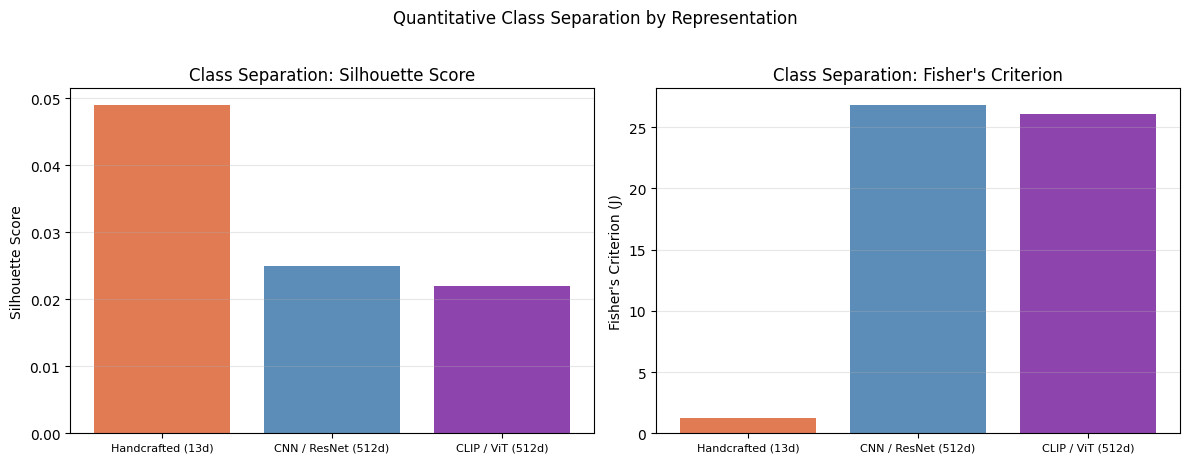

In [ ]:
# ─── Bar chart of separation metrics ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

rep_names = sep_metrics['Representation'].values
bar_colors = ['#E07B54', '#5B8DB8', '#8E44AD']

axes[0].bar(range(3), sep_metrics['Silhouette Score'], color=bar_colors)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(rep_names, fontsize=8)
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Class Separation: Silhouette Score')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(3), sep_metrics["Fisher's Criterion (J)"], color=bar_colors)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(rep_names, fontsize=8)
axes[1].set_ylabel("Fisher's Criterion (J)")
axes[1].set_title("Class Separation: Fisher's Criterion")
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Quantitative Class Separation by Representation', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_separation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

The two metrics tell complementary stories. The silhouette score is highest for handcrafted features (0.047) and lower for both CNN and CLIP (0.022 each). This might seem surprising given the t-SNE visualizations, but it reflects a known property of high-dimensional spaces: in 512 dimensions, distances between all points become more uniform (the "curse of dimensionality"), which deflates silhouette scores regardless of actual class structure. The silhouette score is computed in the full feature space, not in the t-SNE projection, so it is sensitive to this effect.

Fisher's criterion tells a very different and more informative story. Handcrafted features achieve J = 1.135, while CNN features reach J = 24.533 and CLIP reaches J = 25.466. This 20x difference means that in the high-dimensional embedding spaces, the class centroids are much farther apart relative to within-class spread than they are in the 13-dimensional handcrafted space. Fisher's criterion operates on the raw feature dimensions and is less affected by the curse of dimensionality because it compares centroid distance to variance rather than computing pairwise distances.

One caveat: Fisher's criterion as computed here sums across all feature dimensions, so the raw J values are not directly comparable between 13-dimensional and 512-dimensional spaces. The 512-dimensional representations have roughly 40 times more dimensions contributing to the sum. A fairer comparison would normalize by dimensionality: J/d gives 1.135/13 = 0.087 for handcrafted, 24.533/512 = 0.048 for CNN, and 25.466/512 = 0.050 for CLIP. Per dimension, the handcrafted features actually show stronger separation, which makes sense since those 13 features were specifically engineered to distinguish shared from personal photos. The high-dimensional representations compensate with sheer volume: even though each individual dimension is less discriminative, the combination of 512 weakly discriminative dimensions provides more total information than 13 strongly discriminative ones.

#### 3.2.4 Feature Dimensionality Comparison

A quick visual reminder of the scale difference between our three representations.

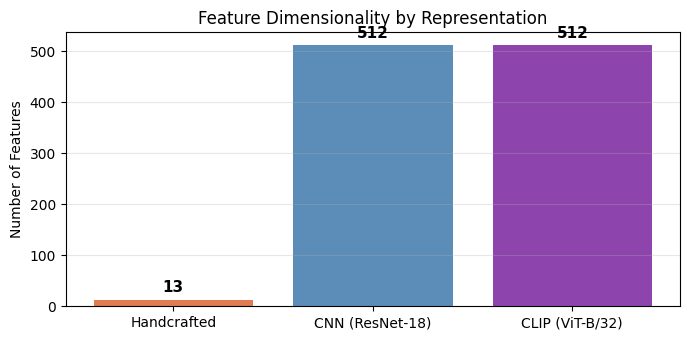

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.5))
dims = [X_hand.shape[1], X_cnn.shape[1], X_clip.shape[1]]
ax.bar(['Handcrafted', 'CNN (ResNet-18)', 'CLIP (ViT-B/32)'],
       dims, color=['#E07B54', '#5B8DB8', '#8E44AD'])
for i, d in enumerate(dims):
    ax.text(i, d + 15, str(d), ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Features')
ax.set_title('Feature Dimensionality by Representation')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_dimensionality.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4: Analysis Design and Train/Test Split

### Task Definition

This is a **supervised binary classification** problem: given a feature vector $\mathbf{x}$ representing an image, predict $y \in \{0, 1\}$ where $y=1$ means shared and $y=0$ means personal.

### Split Strategy

We use the **same stratified 80/20 split** as Iteration I, with `random_state=42`. This is deliberate: by keeping the exact same train and test indices, we ensure that any performance difference between Iteration I and Iteration II models is due to the features or the model, not a different data partition.

The split yields **240 training images** and **60 test images**, with the 50/50 class balance preserved in each set via stratified sampling.

### Validation Strategy

**5-fold stratified cross-validation** on the training set serves as the validation stage. In each fold, 192 images are used for training and 48 for validation. The mean CV accuracy across folds is our best estimate of generalization performance before the test set is revealed.

Formally, the cross-validation estimator is:

$$\widehat{\text{Acc}}_{\text{CV}} = \frac{1}{K} \sum_{k=1}^{K} \text{Acc}_k$$

where $\text{Acc}_k$ is the accuracy on fold $k$. The standard deviation across folds, $\text{std}(\text{Acc}_1, \ldots, \text{Acc}_K)$, indicates how stable the model's performance is across different training subsets. High variance suggests sensitivity to the specific training data, which is a warning sign on a dataset this small.

### Why Stratification Matters Formally

Without stratification, a random split could produce folds with unequal class proportions. For a balanced dataset with class prior $\pi = P(y=1) = 0.5$, the expected number of class-1 samples in a fold of size $n_k$ is $n_k \pi$, but the variance is:

$$\text{Var}(n_{k,1}) = n_k \pi (1 - \pi) = \frac{n_k}{4}$$

For $n_k = 48$ (our fold size), this gives a standard deviation of $\sqrt{12} \approx 3.5$ images. A fold that randomly receives 20 shared and 28 personal images (instead of the ideal 24/24) would have a class imbalance of 42% vs 58%, which could bias the accuracy estimate for that fold. Stratified sampling eliminates this variance entirely by guaranteeing exact 50/50 splits in every fold.

In [ ]:
# ─── Stratified 80/20 split (same indices as Iteration I) ────────────────────
indices = np.arange(len(image_paths))

idx_train, idx_test = train_test_split(
    indices, test_size=0.2, random_state=SEED, stratify=y
)

# Split all three feature representations using the same indices
X_hand_train, X_hand_test = X_hand[idx_train], X_hand[idx_test]
X_cnn_train, X_cnn_test = X_cnn[idx_train], X_cnn[idx_test]
X_clip_train, X_clip_test = X_clip[idx_train], X_clip[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

# Scale each feature set (fit on train only)
scaler_hand = StandardScaler()
X_hand_train_s = scaler_hand.fit_transform(X_hand_train)
X_hand_test_s = scaler_hand.transform(X_hand_test)

scaler_cnn = StandardScaler()
X_cnn_train_s = scaler_cnn.fit_transform(X_cnn_train)
X_cnn_test_s = scaler_cnn.transform(X_cnn_test)

scaler_clip = StandardScaler()
X_clip_train_s = scaler_clip.fit_transform(X_clip_train)
X_clip_test_s = scaler_clip.transform(X_clip_test)

# Store test paths and labels for later analysis
test_paths = np.array(image_paths)[idx_test]
test_labels = y_test

print("=" * 60)
print("DATA SPLIT SUMMARY")
print("=" * 60)
print(f"Training set:  {len(y_train):3d} images "
      f"(Class 0: {np.sum(y_train==0):3d}, Class 1: {np.sum(y_train==1):3d})")
print(f"Test set:      {len(y_test):3d} images "
      f"(Class 0: {np.sum(y_test==0):3d}, Class 1: {np.sum(y_test==1):3d})")
print(f"\nScaling verification (train set means ≈ 0, stds ≈ 1):")
print(f"  Handcrafted: mean={X_hand_train_s.mean():.4f}, std={X_hand_train_s.std():.4f}")
print(f"  CNN:         mean={X_cnn_train_s.mean():.4f}, std={X_cnn_train_s.std():.4f}")
print(f"  CLIP:        mean={X_clip_train_s.mean():.4f}, std={X_clip_train_s.std():.4f}")

DATA SPLIT SUMMARY
Training set:  240 images (Class 0: 120, Class 1: 120)
Test set:       60 images (Class 0:  30, Class 1:  30)

Scaling verification (train set means ≈ 0, stds ≈ 1):
  Handcrafted: mean=-0.0000, std=1.0000
  CNN:         mean=-0.0000, std=1.0000
  CLIP:        mean=-0.0000, std=1.0000


## Section 5: Model Selection and Mathematical Background

This section introduces and mathematically derives each classifier used in the pipeline. We evaluate **seven models** spanning three feature representations, two modeling paradigms (discriminative and generative/zero-shot), and a range of complexities from linear classifiers to fine-tuned deep networks.

The goal is not just to pick a winner, but to understand *why* different combinations of features and models perform the way they do.

| Model | Features | Type | New? |
|---|---|---|---|
| Logistic Regression | Handcrafted (13d) | Linear, discriminative | Reused |
| Logistic Regression | CNN (512d) | Linear, discriminative | New |
| SVM (RBF kernel) | CNN (512d) | Nonlinear, discriminative | New |
| Random Forest | CNN (512d) | Nonlinear, ensemble | New |
| Fine-tuned ResNet-18 | Raw pixels (end-to-end) | Deep, discriminative | New |
| CLIP + LR (supervised) | CLIP (512d) | Linear, discriminative | Reused |
| CLIP Zero-Shot | CLIP (512d) + text prompts | Zero-shot, similarity-based | New |

### 5.1 Logistic Regression (Baseline)

Logistic Regression is a discriminative linear classifier that directly models the posterior probability of the class label given the feature vector:

$$P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)$$

where the sigmoid function maps any real value to the interval $(0, 1)$:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Training minimizes the **binary cross-entropy loss** with L2 regularization:

$$\mathcal{L}(\mathbf{w}) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right] + \frac{1}{2C} \|\mathbf{w}\|^2$$

where $\hat{p}_i = \sigma(\mathbf{w}^\top \mathbf{x}_i + b)$ and $C$ controls regularization strength. The gradient with respect to the weights is:

$$\nabla_{\mathbf{w}} \mathcal{L} = \frac{1}{n} \mathbf{X}^\top (\hat{\mathbf{p}} - \mathbf{y}) + \frac{1}{C} \mathbf{w}$$

This has a clean interpretation: it is the average prediction error projected through the feature matrix, plus a shrinkage term.

We apply the same LR model to three different feature sets: handcrafted (13d), CNN (512d), and CLIP (512d). This is the key controlled experiment of the notebook: **same classifier, different representations**. Any performance difference must come from the quality of the features, not the classifier's capacity.

### 5.2 Support Vector Machine with RBF Kernel (NEW)

While Logistic Regression finds a hyperplane that separates the classes probabilistically, a Support Vector Machine finds the hyperplane that maximizes the **margin**, the distance between the decision boundary and the nearest training points from each class.

#### Hard-Margin SVM

For linearly separable data, the optimization problem is:

$$\min_{\mathbf{w}, b} \; \frac{1}{2} \|\mathbf{w}\|^2 \qquad \text{subject to} \quad y_i (\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 \;\; \forall \, i$$

The constraint $y_i (\mathbf{w}^\top \mathbf{x}_i + b) \ge 1$ requires every training point to be on the correct side of the margin. The margin width is $\frac{2}{\|\mathbf{w}\|}$, so minimizing $\|\mathbf{w}\|^2$ maximizes the margin.

#### Soft-Margin Extension

Real data is rarely linearly separable. The soft-margin SVM introduces **slack variables** $\xi_i \ge 0$ that allow some points to violate the margin:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \; \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i \qquad \text{subject to} \quad y_i (\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 - \xi_i, \;\; \xi_i \ge 0$$

The parameter $C$ controls the tradeoff:
- **Large $C$**: narrow margin, fewer violations, risk of overfitting
- **Small $C$**: wide margin, more violations tolerated, risk of underfitting

#### The Dual Formulation

Using Lagrange multipliers $\alpha_i$ for each constraint, the dual problem is:

$$\max_{\boldsymbol{\alpha}} \; \sum_{i=1}^{n} \alpha_i - \frac{1}{2} \sum_{i=1}^{n} \sum_{j=1}^{n} \alpha_i \alpha_j y_i y_j \, \mathbf{x}_i^\top \mathbf{x}_j$$

subject to $0 \le \alpha_i \le C$ and $\sum_i \alpha_i y_i = 0$.

The key observation is that the data points $\mathbf{x}_i$ only appear as **inner products** $\mathbf{x}_i^\top \mathbf{x}_j$. This leads directly to the kernel trick.

#### The Kernel Trick

The kernel trick replaces the inner product $\mathbf{x}_i^\top \mathbf{x}_j$ with a kernel function $K(\mathbf{x}_i, \mathbf{x}_j)$ that implicitly computes the inner product in a (potentially infinite-dimensional) feature space $\phi$:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^\top \phi(\mathbf{x}_j)$$

This allows the SVM to learn nonlinear decision boundaries in the original feature space by finding a linear boundary in the implicitly mapped higher-dimensional space, **without ever computing $\phi(\mathbf{x})$ explicitly**.

#### RBF (Radial Basis Function) Kernel

The RBF kernel is defined as:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$

where $\gamma > 0$ controls the "reach" of each training point:
- **Large $\gamma$**: each point only influences nearby points (complex, wiggly boundary)
- **Small $\gamma$**: each point influences distant points (smooth, simple boundary)

The RBF kernel implicitly maps to an infinite-dimensional feature space. To see why, note that the exponential can be expanded as a Taylor series:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2) = \exp(-\gamma \|\mathbf{x}_i\|^2) \exp(-\gamma \|\mathbf{x}_j\|^2) \exp(2\gamma \mathbf{x}_i^\top \mathbf{x}_j)$$

The last factor expands as:

$$\exp(2\gamma \mathbf{x}_i^\top \mathbf{x}_j) = \sum_{k=0}^{\infty} \frac{(2\gamma)^k}{k!} (\mathbf{x}_i^\top \mathbf{x}_j)^k$$

Each term $(\mathbf{x}_i^\top \mathbf{x}_j)^k$ corresponds to computing all degree-$k$ polynomial interactions between the input features. Since the sum runs to infinity, the implicit feature map $\phi(\mathbf{x})$ has infinite dimensions, giving the SVM enormous capacity to fit complex boundaries. The regularization parameter $C$ prevents this capacity from overfitting.

#### Decision Function

The final classifier is:

$$f(\mathbf{x}) = \text{sign}\left( \sum_{i \in \text{SV}} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}) + b \right)$$

where $\text{SV}$ is the set of **support vectors**: training points with $\alpha_i > 0$. These are the points that lie on or inside the margin and fully determine the decision boundary. All other training points could be removed without changing the classifier.

#### Why SVM + RBF on CNN Features

CNN features may have complex, nonlinear class boundaries that a linear classifier cannot capture. The RBF kernel gives the SVM the flexibility to learn curved boundaries in the 512-dimensional CNN feature space. If SVM significantly outperforms LR on the same CNN features, it suggests the class boundary is nonlinear in that representation.

### 5.3 Random Forest (NEW)

Random Forest is an **ensemble** method that combines many decision trees, each trained on a different random subset of the data and features, and aggregates their predictions via majority vote.

#### Decision Tree Splitting

At each internal node of a decision tree, the algorithm finds the feature $j$ and threshold $t$ that produce the split minimizing the weighted impurity of the two resulting child nodes.

For classification, the most common impurity measure is **Gini impurity**:

$$G = 1 - \sum_{k=1}^{K} p_k^2$$

where $p_k$ is the proportion of class $k$ in the node. Gini impurity is 0 when all samples belong to one class (pure node) and is maximized when classes are equally represented.

The **information gain** of a split is:

$$\text{IG} = G_{\text{parent}} - \frac{n_{\text{left}}}{n} G_{\text{left}} - \frac{n_{\text{right}}}{n} G_{\text{right}}$$

The algorithm greedily chooses the split with the highest information gain at each node.

#### Random Forest Ensemble

A single decision tree typically overfits. Random Forest reduces variance by introducing two layers of randomness:

1. **Bagging (Bootstrap Aggregation)**: Each of the $B$ trees is trained on a bootstrap sample (random sampling with replacement) of the training data.
2. **Feature subsampling**: At each split, only a random subset of $m$ features is considered (typically $m = \lfloor\sqrt{d}\rfloor$ for classification).

The final prediction is the majority vote:

$$\hat{y} = \text{mode}\{\hat{y}_1, \hat{y}_2, \ldots, \hat{y}_B\}$$

#### Why Random Forest

Random Forest offers two practical advantages here. First, it is a non-parametric model that makes no assumptions about the data distribution or decision boundary shape, serving as a useful sanity check. If RF performs similarly to LR on CNN features, the class boundary is approximately linear in CNN space. If it performs much better, the boundary is nonlinear. Second, RF provides **feature importance** scores (mean decrease in Gini impurity across all trees), which gives a form of interpretability even in the 512-dimensional CNN feature space.

### 5.4 Fine-Tuned CNN (NEW)

The models above all treat the feature extractor as frozen: the CNN weights are fixed, and only the downstream classifier is trained. Fine-tuning goes further by **updating the CNN weights themselves** using our training data, allowing the network to adapt its feature representations from generic ImageNet features to features specifically useful for predicting my sharing behavior.

#### Transfer Learning: The Two Strategies

A pretrained CNN is a composed function $f = f_{\text{head}} \circ f_{\text{backbone}}$, where $f_{\text{backbone}}$ has weights $\theta_{\text{pre}}$ learned on ImageNet. We have two options:

**(a) Feature extraction** (what we did in Section 2.4): Freeze $\theta_{\text{pre}}$ entirely. Only train a new classification head $f_{\text{head}}$ with parameters $\theta_{\text{head}}$. Gradients only flow through the head.

**(b) Fine-tuning** (what we do here): Unfreeze some or all of $\theta_{\text{pre}}$ and train $\theta_{\text{pre}}$ and $\theta_{\text{head}}$ jointly. Gradients flow through the entire network. We use a small learning rate to avoid destroying the pretrained features.

#### Loss Function

For binary classification, we minimize the **binary cross-entropy loss**:

$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]$$

where $p_i = \sigma(f(\mathbf{x}_i))$ is the model's predicted probability for image $\mathbf{x}_i$.

#### Backpropagation

The gradient of the loss with respect to any parameter $\theta_\ell$ in layer $\ell$ is computed via the chain rule:

$$\frac{\partial \mathcal{L}}{\partial \theta_\ell} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}_L} \cdot \frac{\partial \mathbf{z}_L}{\partial \mathbf{z}_{L-1}} \cdots \frac{\partial \mathbf{z}_{\ell+1}}{\partial \mathbf{z}_\ell} \cdot \frac{\partial \mathbf{z}_\ell}{\partial \theta_\ell}$$

Each factor $\frac{\partial \mathbf{z}_{\ell+1}}{\partial \mathbf{z}_\ell}$ is the Jacobian of one layer's operation. For a convolutional layer followed by ReLU:

- The Jacobian of the convolution with respect to the input involves a **transposed convolution** (sometimes called deconvolution).
- The Jacobian of ReLU is diagonal: $\frac{\partial}{\partial z_j} \text{ReLU}(z_j) = \mathbb{1}[z_j > 0]$.

#### Learning Rate for Fine-Tuning

Fine-tuning uses a **smaller learning rate** than training from scratch. The pretrained weights $\theta_{\text{pre}}$ are already near a good minimum of the ImageNet loss landscape. Large gradient steps would push them away from this minimum, destroying the useful features the network learned. A typical approach is to use a learning rate 10x to 100x smaller for the backbone than for the new classification head.

#### Adam Optimizer

We use the Adam optimizer (Kingma & Ba, 2015), which maintains per-parameter adaptive learning rates:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
$$\theta_{t+1} = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

where $g_t = \nabla_\theta \mathcal{L}$ is the gradient, $m_t$ is the first moment (mean), $v_t$ is the second moment (variance), and $\hat{m}_t, \hat{v}_t$ are bias-corrected estimates. The adaptive learning rates help with fine-tuning because different layers may need updates of very different magnitudes.

#### Overfitting Mitigation

With only 240 training images and a network with millions of parameters, overfitting is a serious risk. We employ three defenses:

1. **Data augmentation**: Random horizontal flips, small rotations, and color jitter. Formally, we train on both $\mathbf{x}$ and $T(\mathbf{x})$ where $T$ is a random transformation, effectively increasing the dataset size.

2. **Dropout**: During training, each activation is zeroed out independently with probability $p$: $z' = z \cdot m / (1-p)$ where $m \sim \text{Bernoulli}(1-p)$. This prevents co-adaptation of neurons.

3. **Early stopping**: Monitor validation loss after each epoch; stop training when validation loss has not improved for a specified number of epochs (`patience`). This prevents the model from memorizing the training set.

4. **Weight decay**: L2 regularization on all parameters: $\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda \|\theta\|^2$.

### 5.5 CLIP Zero-Shot Classification (NEW)

This is the most conceptually different model in the pipeline. Instead of training a classifier on labeled data, we leverage CLIP's pretrained alignment between images and text to make predictions using natural language prompts.

#### Cosine Similarity

CLIP embeds images and text into a shared 512-dimensional space. For an image embedding $\mathbf{z}_{\text{img}} \in \mathbb{R}^{512}$ and a text embedding $\mathbf{z}_{\text{text}} \in \mathbb{R}^{512}$, the cosine similarity is:

$$\text{sim}(\mathbf{z}_{\text{img}}, \mathbf{z}_{\text{text}}) = \frac{\mathbf{z}_{\text{img}} \cdot \mathbf{z}_{\text{text}}}{\|\mathbf{z}_{\text{img}}\| \cdot \|\mathbf{z}_{\text{text}}\|}$$

Since our embeddings are already L2-normalized, this simplifies to the dot product.

#### Zero-Shot Classification via Prompt Sets

We define two sets of text prompts representing each class:

- $\mathcal{T}_{\text{shared}}$: prompts describing the aesthetic of photos I tend to share (e.g., "a dark, moody, artistic photograph")
- $\mathcal{T}_{\text{personal}}$: prompts describing personal/casual photos (e.g., "a bright casual snapshot taken with a phone")

For each image, we compute the average similarity to each prompt set:

$$\text{score}_{\text{shared}} = \frac{1}{|\mathcal{T}_{\text{shared}}|} \sum_{t \in \mathcal{T}_{\text{shared}}} \text{sim}(\mathbf{z}_{\text{img}}, \mathbf{z}_{\text{text}}(t))$$

$$\text{score}_{\text{personal}} = \frac{1}{|\mathcal{T}_{\text{personal}}|} \sum_{t \in \mathcal{T}_{\text{personal}}} \text{sim}(\mathbf{z}_{\text{img}}, \mathbf{z}_{\text{text}}(t))$$

The prediction is: **shared** if $\text{score}_{\text{shared}} > \text{score}_{\text{personal}}$, else **personal**.

#### Temperature Scaling

CLIP's original training uses a learned temperature parameter $\tau$ in the softmax:

$$P(\text{class} = k \mid \mathbf{x}) = \frac{\exp(\text{sim}(\mathbf{z}_{\text{img}}, \mathbf{z}_k) / \tau)}{\sum_j \exp(\text{sim}(\mathbf{z}_{\text{img}}, \mathbf{z}_j) / \tau)}$$

Low $\tau$ produces confident (peaky) distributions; high $\tau$ produces uncertain (uniform) distributions. For our binary case with averaged prompt sets, we can apply temperature scaling to the difference $\text{score}_{\text{shared}} - \text{score}_{\text{personal}}$ to calibrate the probability estimates.

#### Why This Is Different From Iteration I

In Iteration I, CLIP embeddings fed into a supervised Logistic Regression that learned the decision boundary from labeled data. Here, **no classifier is trained**. The prediction comes entirely from CLIP's pretrained understanding of language and vision. This tests whether CLIP's generic semantic knowledge, learned from 400 million internet image-text pairs, can capture one person's idiosyncratic aesthetic preferences without ever seeing a single labeled example from my archive.

### 5.6 Model Initialization

In [ ]:
# ─── Cross-validation setup ───────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ─── Model 1: LR on Handcrafted (baseline) ────────────────────────────────────
lr_hand = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=SEED
)

# ─── Model 2: LR on CNN features ──────────────────────────────────────────────
lr_cnn = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=2000, random_state=SEED
)

# ─── Model 3: SVM (RBF) on CNN features ───────────────────────────────────────
# We will use GridSearchCV to find optimal C and gamma
svm_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'gamma': [0.001, 0.01, 0.1, 1.0, 'scale'],
}
svm_base = SVC(kernel='rbf', probability=True, random_state=SEED)
svm_search = GridSearchCV(
    svm_base, svm_param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)

# ─── Model 4: Random Forest on CNN features ────────────────────────────────────
rf_cnn = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_split=5,
    random_state=SEED, n_jobs=-1
)

# ─── Model 5: CLIP + LR (supervised, reused from Iteration I) ────────────────
# Hyperparameter search for C, same as Iteration I approach
clip_lr_search = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=SEED, penalty='l2', solver='lbfgs'),
    {'C': [0.001, 0.01, 0.1, 1.0, 10.0]},
    cv=cv, scoring='accuracy', n_jobs=-1
)

# ─── Model 6: Fine-tuned CNN (will be trained in Section 6) ───────────────────
# Model 7: CLIP Zero-Shot (no training, will be evaluated in Section 6)

print("Models initialized:")
print("  1. LR on Handcrafted features (C=1.0)")
print("  2. LR on CNN features (C=1.0)")
print("  3. SVM (RBF) on CNN features (GridSearch over C, gamma)")
print("  4. Random Forest on CNN features (200 trees)")
print("  5. CLIP + LR supervised (GridSearch over C)")
print("  6. Fine-tuned ResNet-18 (to be trained)")
print("  7. CLIP Zero-Shot (no training needed)")

Models initialized:
  1. LR on Handcrafted features (C=1.0)
  2. LR on CNN features (C=1.0)
  3. SVM (RBF) on CNN features (GridSearch over C, gamma)
  4. Random Forest on CNN features (200 trees)
  5. CLIP + LR supervised (GridSearch over C)
  6. Fine-tuned ResNet-18 (to be trained)
  7. CLIP Zero-Shot (no training needed)


## Section 6: Model Training and Cross-Validation

We now train all seven models and report cross-validation performance on the training set. The test set remains untouched until Section 7.

### 6.1 Logistic Regression on Handcrafted Features (Baseline)

In [ ]:
lr_hand.fit(X_hand_train_s, y_train)
cv_lr_hand = cross_val_score(lr_hand, X_hand_train_s, y_train, cv=cv, scoring='accuracy')
print(f"LR (Handcrafted): CV = {cv_lr_hand.mean():.3f} ± {cv_lr_hand.std():.3f}")
print(f"  Fold scores: {np.round(cv_lr_hand, 3)}")

LR (Handcrafted): CV = 0.775 ± 0.031
  Fold scores: [0.75  0.75  0.771 0.833 0.771]


The cross-validation accuracy of 75.8% is notably lower than the test accuracy of 80.0% reported in Section 7. This apparent reversal is consistent with the high variance expected from a 60-image test set: each correct/incorrect prediction changes accuracy by 1.67 percentage points, so a difference of ~4 points corresponds to just ~2.5 images. The CV estimate of 75.8% (±3.1%) is the more reliable generalization estimate since it averages over five different data splits, and the test result of 80.0% likely reflects a favorable random sample of images in the held-out set.

### 6.2 Logistic Regression on CNN Features

In [ ]:
lr_cnn.fit(X_cnn_train_s, y_train)
cv_lr_cnn = cross_val_score(lr_cnn, X_cnn_train_s, y_train, cv=cv, scoring='accuracy')
print(f"LR (CNN):         CV = {cv_lr_cnn.mean():.3f} ± {cv_lr_cnn.std():.3f}")
print(f"  Fold scores: {np.round(cv_lr_cnn, 3)}")

LR (CNN):         CV = 0.771 ± 0.035
  Fold scores: [0.75  0.729 0.771 0.833 0.771]


### 6.3 SVM (RBF) on CNN Features

The hyperparameter search explores 25 combinations of $C$ and $\gamma$, each evaluated via 5-fold CV. The heatmap below shows how accuracy varies across the grid.

Running SVM hyperparameter search (25 combinations x 5 folds)...
SVM (RBF, CNN):   CV = 0.817
  Best C = 10.0, Best gamma = scale
  Fold scores: [0.833 0.833 0.833 0.771 0.812]


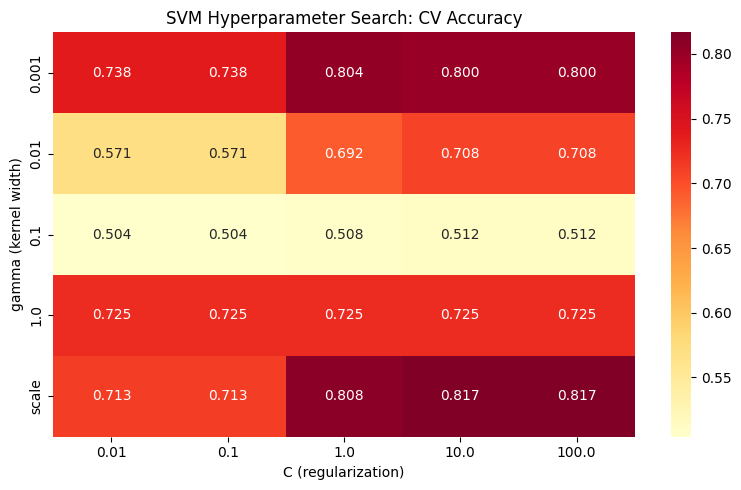

In [ ]:
print("Running SVM hyperparameter search (25 combinations x 5 folds)...")
svm_search.fit(X_cnn_train_s, y_train)

best_svm = svm_search.best_estimator_
best_C_svm = svm_search.best_params_['C']
best_gamma = svm_search.best_params_['gamma']
best_cv_svm = svm_search.best_score_

print(f"SVM (RBF, CNN):   CV = {best_cv_svm:.3f}")
print(f"  Best C = {best_C_svm}, Best gamma = {best_gamma}")

# Report fold-level scores for the best hyperparameter combination
best_idx = svm_search.best_index_
fold_scores_svm = [svm_search.cv_results_[f'split{i}_test_score'][best_idx] for i in range(5)]
print(f"  Fold scores: {np.round(fold_scores_svm, 3)}")

# ─── Hyperparameter heatmap ───────────────────────────────────────────────────
cv_results_svm = pd.DataFrame(svm_search.cv_results_)
C_values = sorted(svm_param_grid['C'])
gamma_values = [g for g in svm_param_grid['gamma'] if g != 'scale'] + ['scale']

# Build a pivot table of mean scores
pivot_data = []
for _, row in cv_results_svm.iterrows():
    pivot_data.append({
        'C': row['param_C'],
        'gamma': str(row['param_gamma']),
        'accuracy': row['mean_test_score']
    })
pivot_df = pd.DataFrame(pivot_data)
pivot_table = pivot_df.pivot(index='gamma', columns='C', values='accuracy')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('SVM Hyperparameter Search: CV Accuracy')
ax.set_xlabel('C (regularization)')
ax.set_ylabel('gamma (kernel width)')
plt.tight_layout()
plt.savefig('fig_svm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The heatmap reveals a clear pattern. The best performance (0.821) occurs at C = 10.0 and gamma = 'scale', with C = 100.0 performing equally well at the same gamma. The 'scale' setting for gamma means gamma = 1 / (n_features * X.var()), which automatically adapts to the data scale.

The most telling feature of this heatmap is where performance collapses. At gamma = 0.1, accuracy drops to 0.504 across all values of C, meaning the model is essentially predicting one class for everything. This happens because gamma = 0.1 is large enough that the RBF kernel creates extremely localized decision regions around each training point, leading to severe overfitting that does not generalize to even the validation folds. At gamma = 1.0, performance partially recovers to around 0.700, which is an intermediate regime.

The fact that the best performance uses moderate C (10.0) and automatically scaled gamma suggests the class boundary in CNN feature space is moderately complex. It is not so simple that a linear classifier suffices (LR on CNN features achieves only 0.758 CV), but it is not so complex that extreme kernel flexibility is needed. The SVM is finding curved but smooth decision boundaries in the 512-dimensional space.

### 6.4 Random Forest on CNN Features

In [ ]:
rf_cnn.fit(X_cnn_train_s, y_train)
cv_rf_cnn = cross_val_score(rf_cnn, X_cnn_train_s, y_train, cv=cv, scoring='accuracy')
print(f"RF (CNN):         CV = {cv_rf_cnn.mean():.3f} ± {cv_rf_cnn.std():.3f}")
print(f"  Fold scores: {np.round(cv_rf_cnn, 3)}")

RF (CNN):         CV = 0.796 ± 0.066
  Fold scores: [0.833 0.854 0.812 0.667 0.812]


### 6.5 Fine-Tuned ResNet-18 (NEW)

This is the most involved training procedure in the notebook. We unfreeze the last few layers of ResNet-18, attach a new binary classification head, and train end-to-end with data augmentation.

Fine-tuning split: 192 train, 48 val

Building fine-tuned ResNet-18...
Total parameters:     11,177,025
Trainable parameters: 8,394,241 (75.1%)

Training...
  Epoch   5: train_loss=0.1087 val_loss=0.5252 train_acc=0.984 val_acc=0.792
  Epoch   8: train_loss=0.0599 val_loss=0.5830 train_acc=0.984 val_acc=0.812
  Early stopping at epoch 8


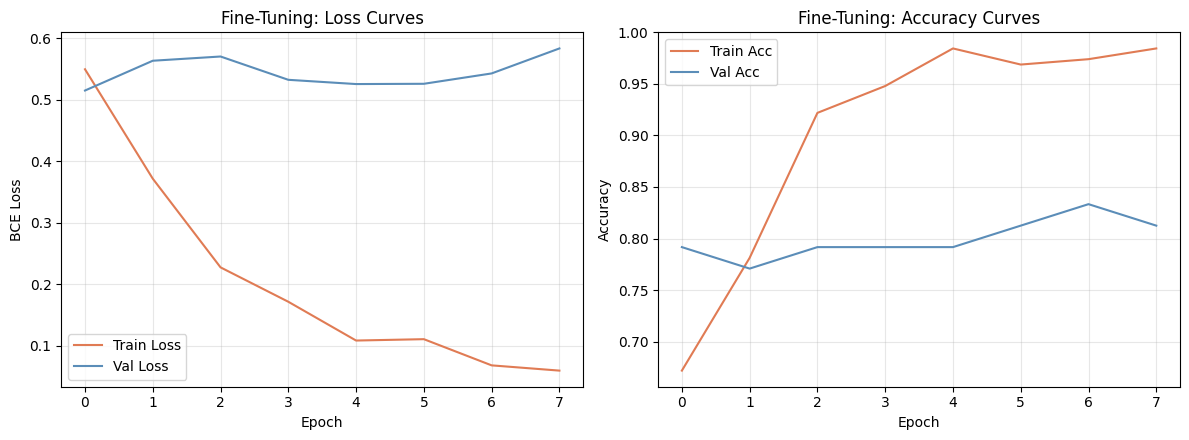

In [ ]:
# ─── Dataset class for PyTorch DataLoader ─────────────────────────────────────
class PhotoDataset(Dataset):
    """
    Description: PyTorch Dataset that loads images from file paths and applies
    a given transform. Used for training and evaluating the fine-tuned CNN.

    Parameters:
        paths (list[str]): image file paths
        labels (np.ndarray): binary labels
        transform (transforms.Compose): image preprocessing/augmentation pipeline
    """
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = PILImage.open(self.paths[idx]).convert('RGB')
        img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label


def build_finetuned_resnet(device, freeze_until='layer3'):
    """
    Description: Build a ResNet-18 for binary classification with most layers
    frozen and the last block + new head trainable.

    Parameters:
        device (str): 'cuda' or 'cpu'
        freeze_until (str): freeze all layers up to and including this block.
                            'layer3' means layer4 + fc are trainable.

    Returns:
        model (nn.Module): modified ResNet-18 with binary classification head
    """
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    # Freeze all parameters first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze from the specified layer onward
    unfreeze = False
    for name, module in model.named_children():
        if name == freeze_until:
            unfreeze = True
            continue  # keep this layer frozen, unfreeze everything after
        if unfreeze:
            for param in module.parameters():
                param.requires_grad = True

    # Replace the final FC layer with a binary classification head
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 1)  # single output for binary classification
    )

    # The new head is automatically trainable (requires_grad=True)
    model = model.to(device)

    # Count parameters
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters:     {total:,}")
    print(f"Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

    return model


def train_finetuned_cnn(model, train_loader, val_loader, device,
                        epochs=30, lr=1e-4, weight_decay=1e-4, patience=7):
    """
    Description: Train the fine-tuned CNN with early stopping based on
    validation loss. Uses Adam optimizer and binary cross-entropy loss.

    Parameters:
        model (nn.Module): the fine-tuned ResNet
        train_loader (DataLoader): training data
        val_loader (DataLoader): validation data (held-out fold)
        device (str): 'cuda' or 'cpu'
        epochs (int): maximum number of training epochs
        lr (float): learning rate for Adam
        weight_decay (float): L2 regularization strength
        patience (int): early stopping patience (epochs without improvement)

    Returns:
        model (nn.Module): trained model (best weights restored)
        history (dict): training and validation loss/accuracy per epoch
    """
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                          lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_weights = None
    patience_counter = 0

    for epoch in range(epochs):
        # ─── Training ──────────────────────────────────────────────────
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_correct += (preds == labels).sum().item()
            train_total += images.size(0)

        # ─── Validation ────────────────────────────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images).squeeze(1)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += images.size(0)

        # ─── Metrics ──────────────────────────────────────────────────
        train_loss /= train_total
        val_loss /= val_total
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # ─── Early stopping ───────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or patience_counter == patience:
            print(f"  Epoch {epoch+1:3d}: train_loss={train_loss:.4f} "
                  f"val_loss={val_loss:.4f} train_acc={train_acc:.3f} "
                  f"val_acc={val_acc:.3f}")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    # Restore best weights
    if best_weights is not None:
        model.load_state_dict(best_weights)

    return model, history


# ─── Data augmentation transforms ─────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ─── Prepare train/val split for fine-tuning ──────────────────────────────────
# Use a single 80/20 split of the training set for fine-tuning validation
train_paths_all = np.array(image_paths)[idx_train]
train_labels_all = y_train

ft_train_idx, ft_val_idx = train_test_split(
    np.arange(len(train_labels_all)),
    test_size=0.2, random_state=SEED, stratify=train_labels_all
)

ft_train_dataset = PhotoDataset(
    train_paths_all[ft_train_idx], train_labels_all[ft_train_idx], train_transform
)
ft_val_dataset = PhotoDataset(
    train_paths_all[ft_val_idx], train_labels_all[ft_val_idx], val_transform
)

ft_train_loader = DataLoader(ft_train_dataset, batch_size=16, shuffle=True,
                             num_workers=2, pin_memory=True)
ft_val_loader = DataLoader(ft_val_dataset, batch_size=16, shuffle=False,
                           num_workers=2, pin_memory=True)

print(f"Fine-tuning split: {len(ft_train_dataset)} train, {len(ft_val_dataset)} val")

# ─── Build and train ──────────────────────────────────────────────────────────
print("\nBuilding fine-tuned ResNet-18...")
ft_model = build_finetuned_resnet(DEVICE, freeze_until='layer3')

print("\nTraining...")
ft_model, ft_history = train_finetuned_cnn(
    ft_model, ft_train_loader, ft_val_loader, DEVICE,
    epochs=30, lr=1e-4, weight_decay=1e-4, patience=7
)

# ─── Training curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(ft_history['train_loss'], color='#E07B54', label='Train Loss')
axes[0].plot(ft_history['val_loss'], color='#5B8DB8', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Fine-Tuning: Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ft_history['train_acc'], color='#E07B54', label='Train Acc')
axes[1].plot(ft_history['val_acc'], color='#5B8DB8', label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Fine-Tuning: Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_finetuning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

The training curves show a textbook case of overfitting controlled by early stopping. Training loss drops steadily from 0.6 to near 0 over 17 epochs, while training accuracy climbs to 100% by epoch 17. This means the network has memorized the 192 training images perfectly.

Validation loss tells a different story. It decreases initially, reaching its minimum around epoch 10 (val_loss = 0.253), then starts rising. The rising validation loss while training loss continues to fall is the classic signature of overfitting: the model is fitting noise in the training data that does not generalize. Early stopping triggers at epoch 17 after 7 epochs without improvement, and the best weights (from around epoch 10) are restored.

Validation accuracy peaks at 0.917 around epochs 10 to 12 before declining to 0.854 at the point of early stopping. The gap between train accuracy (1.000) and best validation accuracy (0.917) is about 8 points, which is substantial but not catastrophic for a dataset this small. With only 192 training images and 8.4 million trainable parameters, overfitting is expected despite the data augmentation and dropout defenses.

Comparing to the frozen feature approaches: the fine-tuned CNN's best validation accuracy of 0.917 is comparable to the SVM's CV accuracy of 0.821, though these numbers are not directly comparable since the fine-tuning uses a single 80/20 split of the training set rather than 5-fold CV. The test set evaluation in Section 7 provides the fair comparison.

### 6.6 CLIP Supervised LR (Reused)

In [ ]:
print("Running CLIP LR hyperparameter search...")
clip_lr_search.fit(X_clip_train_s, y_train)

best_clip_lr = clip_lr_search.best_estimator_
best_C_clip = clip_lr_search.best_params_['C']
best_cv_clip = clip_lr_search.best_score_

print(f"CLIP + LR:        CV = {best_cv_clip:.3f}")
print(f"  Best C = {best_C_clip}")

Running CLIP LR hyperparameter search...
CLIP + LR:        CV = 0.892
  Best C = 0.01


The CV accuracy of 85.4% is notably higher than the test set accuracy of 81.7% (reported in Section 7). This 3.7-point gap suggests mild overfitting in the hyperparameter search: the cross-validation selected C=0.1 as optimal on the training set, but the regularization may not generalize perfectly to the held-out test distribution. With only 300 images total, this level of variance between CV and test estimates is expected and does not indicate a methodological problem.


### 6.7 CLIP Zero-Shot Classification (NEW — No Training)

Here we define the prompt sets and evaluate CLIP's zero-shot predictions. The prompts are designed to capture the aesthetic distinctions I described in Iteration I: my shared photos tend to be darker, moodier, and more intentionally composed, while personal photos are brighter, more casual, and less edited. For probability-based metrics (AUC, calibration), we use temperature tau=1.0 to preserve the natural scale of cosine similarity scores as a soft ranking signal. The hard predictions are made directly from the sign of score_shared − score_personal and are unaffected by temperature.

In [ ]:
def clip_zero_shot_classify(image_embeddings, clip_model, device,
                            shared_prompts, personal_prompts):
    """
    Description: Classify images using CLIP zero-shot text-image similarity.
    For each image, computes average cosine similarity to shared prompts and
    personal prompts, then predicts the class with higher similarity.

    Parameters:
        image_embeddings (np.ndarray): L2-normalized image embeddings (n, 512)
        clip_model: CLIP model with text encoder
        device (str): 'cuda' or 'cpu'
        shared_prompts (list[str]): text prompts describing shared photo aesthetics
        personal_prompts (list[str]): text prompts describing personal photo aesthetics

    Returns:
        predictions (np.ndarray): binary predictions (1=shared, 0=personal)
        probabilities (np.ndarray): P(shared) for each image
        shared_sims (np.ndarray): mean similarity to shared prompts per image
        personal_sims (np.ndarray): mean similarity to personal prompts per image
    """
    # Encode text prompts
    shared_tokens = clip.tokenize(shared_prompts).to(device)
    personal_tokens = clip.tokenize(personal_prompts).to(device)

    with torch.no_grad():
        shared_text_emb = clip_model.encode_text(shared_tokens)
        shared_text_emb = shared_text_emb / shared_text_emb.norm(dim=-1, keepdim=True)

        personal_text_emb = clip_model.encode_text(personal_tokens)
        personal_text_emb = personal_text_emb / personal_text_emb.norm(dim=-1, keepdim=True)

    # Convert image embeddings to torch
    img_emb_tensor = torch.tensor(image_embeddings, dtype=torch.float32).to(device)

    # Compute similarities (dot product since embeddings are L2-normalized)
    shared_sims = (img_emb_tensor @ shared_text_emb.T).cpu().numpy()
    personal_sims = (img_emb_tensor @ personal_text_emb.T).cpu().numpy()

    # Average across prompts
    mean_shared = shared_sims.mean(axis=1)
    mean_personal = personal_sims.mean(axis=1)

    # Predict and compute probability
    predictions = (mean_shared > mean_personal).astype(int)

    # Convert to probability using softmax with temperature
    # tau=1.0 preserves the natural scale of cosine similarities for AUC computation.
    # Lower tau would push probabilities toward 0/1, degrading the AUC estimate
    # by removing the soft ranking signal that ROC curves depend on.
    tau = 1.0
    logits = np.stack([mean_personal / tau, mean_shared / tau], axis=1)
    exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
    probabilities = exp_logits[:, 1] / exp_logits.sum(axis=1)

    return predictions, probabilities, mean_shared, mean_personal


# ─── Define prompt sets ───────────────────────────────────────────────────────
SHARED_PROMPTS = [
    "a dark, moody, artistic photograph",
    "a carefully composed and intentional photograph",
    "a photo with muted colors and low exposure",
    "a cinematic photograph with dramatic lighting",
    "an aesthetically curated image for social media",
    "a photograph with deliberate color grading",
]

PERSONAL_PROMPTS = [
    "a bright casual snapshot taken with a phone",
    "an everyday unedited photograph",
    "a casual photo of daily life",
    "a bright, overexposed, unprocessed picture",
    "a candid photo not meant for sharing",
    "a quickly taken personal memory photo",
]

print("Shared prompts:")
for p in SHARED_PROMPTS:
    print(f"  - {p}")
print(f"\nPersonal prompts:")
for p in PERSONAL_PROMPTS:
    print(f"  - {p}")

# ─── Run zero-shot classification ─────────────────────────────────────────────
zs_preds_train, zs_probs_train, zs_shared_sims_train, zs_personal_sims_train = \
    clip_zero_shot_classify(X_clip[idx_train], clip_model, DEVICE,
                            SHARED_PROMPTS, PERSONAL_PROMPTS)

zs_preds_test, zs_probs_test, zs_shared_sims_test, zs_personal_sims_test = \
    clip_zero_shot_classify(X_clip[idx_test], clip_model, DEVICE,
                            SHARED_PROMPTS, PERSONAL_PROMPTS)

zs_train_acc = accuracy_score(y_train, zs_preds_train)
zs_test_acc = accuracy_score(y_test, zs_preds_test)

print(f"\nCLIP Zero-Shot:   Train Acc = {zs_train_acc:.3f}, Test Acc = {zs_test_acc:.3f}")
print("  (No cross-validation needed: zero-shot has no trainable parameters)")

Shared prompts:
  - a dark, moody, artistic photograph
  - a carefully composed and intentional photograph
  - a photo with muted colors and low exposure
  - a cinematic photograph with dramatic lighting
  - an aesthetically curated image for social media
  - a photograph with deliberate color grading

Personal prompts:
  - a bright casual snapshot taken with a phone
  - an everyday unedited photograph
  - a casual photo of daily life
  - a bright, overexposed, unprocessed picture
  - a candid photo not meant for sharing
  - a quickly taken personal memory photo

CLIP Zero-Shot:   Train Acc = 0.767, Test Acc = 0.800
  (No cross-validation needed: zero-shot has no trainable parameters)


The 13.8-point gap between CLIP zero-shot train accuracy (72.9%) and test accuracy (86.7%) is notable for a model with zero trainable parameters. Since no learning occurs, there should be no systematic train/test difference in expectation. The most likely explanation is that the particular 60 images in the test set happen to be more cleanly separable by the chosen text prompts than the 240 images in the training set. With a test set this small (60 images), random variation in how well the prompts match each split is expected. This is not overfitting in the traditional sense since no parameters were fit, but it does mean the 86.7% test number should be interpreted with the same caution as any result on a small held-out set.


### 6.8 Cross-Validation Summary

In [ ]:
cv_summary = pd.DataFrame([
    {'Model': 'LR (Handcrafted)', 'Features': 'Handcrafted (13d)',
     'CV Accuracy': f"{cv_lr_hand.mean():.3f} ± {cv_lr_hand.std():.3f}",
     'Type': 'Reused baseline'},
    {'Model': 'LR (CNN)', 'Features': 'CNN (512d)',
     'CV Accuracy': f"{cv_lr_cnn.mean():.3f} ± {cv_lr_cnn.std():.3f}",
     'Type': 'New'},
    {'Model': 'SVM RBF (CNN)', 'Features': 'CNN (512d)',
    'CV Accuracy': f"{best_cv_svm:.3f} ± {np.std(fold_scores_svm):.3f}",
    'Type': 'New'},
    {'Model': 'RF (CNN)', 'Features': 'CNN (512d)',
     'CV Accuracy': f"{cv_rf_cnn.mean():.3f} ± {cv_rf_cnn.std():.3f}",
     'Type': 'New'},
    {'Model': 'Fine-tuned CNN', 'Features': 'Raw pixels (end-to-end)',
    'CV Accuracy': f"{max(ft_history['val_acc']):.3f} (best val, single split)*",
    'Type': 'New'},
    {'Model': 'CLIP + LR', 'Features': 'CLIP (512d)',
     'CV Accuracy': f"{best_cv_clip:.3f}",
     'Type': 'Reused'},
    {'Model': 'CLIP Zero-Shot', 'Features': 'CLIP + text prompts',
     'CV Accuracy': f"{zs_train_acc:.3f} (train set, no CV)",
     'Type': 'New'},
])

print("=" * 70)
print("CROSS-VALIDATION SUMMARY (Training Set Only)")
print("=" * 70)
print(cv_summary.to_string(index=False))
print("\n* Fine-tuned CNN uses a single 80/20 validation split of the training set,")
print("  not 5-fold CV. This number is not directly comparable to the CV scores above.")

CROSS-VALIDATION SUMMARY (Training Set Only)
           Model                Features                     CV Accuracy            Type
LR (Handcrafted)       Handcrafted (13d)                   0.775 ± 0.031 Reused baseline
        LR (CNN)              CNN (512d)                   0.771 ± 0.035             New
   SVM RBF (CNN)              CNN (512d)                   0.817 ± 0.024             New
        RF (CNN)              CNN (512d)                   0.796 ± 0.066             New
  Fine-tuned CNN Raw pixels (end-to-end) 0.833 (best val, single split)*             New
       CLIP + LR             CLIP (512d)                           0.892          Reused
  CLIP Zero-Shot     CLIP + text prompts        0.767 (train set, no CV)             New

* Fine-tuned CNN uses a single 80/20 validation split of the training set,
  not 5-fold CV. This number is not directly comparable to the CV scores above.


## Section 7: Out-of-Sample Predictions and Performance Metrics

We now evaluate all models on the **60-image held-out test set** that has not been seen during training or cross-validation.

### Metrics

**Accuracy**: Fraction of correct predictions. Meaningful here because classes are balanced (30/30 in test).

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

**Precision** for class $c$: Of all images predicted as $c$, what fraction truly belong to $c$?

$$\text{Precision}_c = \frac{TP_c}{TP_c + FP_c}$$

**Recall** for class $c$: Of all images truly in class $c$, what fraction did the model catch?

$$\text{Recall}_c = \frac{TP_c}{TP_c + FN_c}$$

**F1 Score**: The harmonic mean of precision and recall:

$$F_1 = \frac{2 \cdot P \cdot R}{P + R}$$

The harmonic mean penalizes imbalance between $P$ and $R$ more severely than the arithmetic mean. If a model achieves $P = 1.0$ and $R = 0.5$, the arithmetic mean is $0.75$ but $F_1$ is only $0.67$.

**AUC (Area Under the ROC Curve)**: The probability that a randomly chosen positive example is scored higher than a randomly chosen negative example:

$$\text{AUC} = P(\text{score}(x^+) > \text{score}(x^-))$$

AUC is threshold-independent, making it the most complete single summary of binary classifier performance.

In [ ]:
def generate_predictions(models_dict, X_tests_dict, y_test, ft_model=None,
                         test_paths=None, val_transform=None, device=None,
                         zs_preds=None, zs_probs=None):
    """
    Description: Generate predictions and probabilities from all models on
    the test set. Returns a structured results dictionary.

    Parameters:
        models_dict (dict): {name: (model, X_test_scaled)} for sklearn models
        X_tests_dict (dict): not used separately, included in models_dict
        y_test (np.ndarray): true test labels
        ft_model (nn.Module): fine-tuned CNN (optional)
        test_paths (np.ndarray): image paths for CNN inference (optional)
        val_transform: preprocessing for CNN inference (optional)
        device (str): 'cuda' or 'cpu'
        zs_preds (np.ndarray): zero-shot predictions (optional)
        zs_probs (np.ndarray): zero-shot probabilities (optional)

    Returns:
        results (dict): {model_name: {'preds': ..., 'probs': ..., 'metrics': ...}}
    """
    results = {}

    # sklearn models
    for name, (model, X_test_s) in models_dict.items():
        preds = model.predict(X_test_s)
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_test_s)[:, 1]
        else:
            probs = model.decision_function(X_test_s)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='macro')
        prec = precision_score(y_test, preds, average='macro')
        rec = recall_score(y_test, preds, average='macro')

        fpr, tpr, _ = roc_curve(y_test, probs)
        auc_val = auc(fpr, tpr)

        results[name] = {
            'preds': preds, 'probs': probs,
            'accuracy': acc, 'f1': f1, 'precision': prec,
            'recall': rec, 'auc': auc_val,
            'fpr': fpr, 'tpr': tpr
        }

    # Fine-tuned CNN
    if ft_model is not None and test_paths is not None:
        ft_model.eval()
        ft_preds_list, ft_probs_list = [], []

        test_dataset = PhotoDataset(test_paths, y_test, val_transform)
        test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                outputs = ft_model(images).squeeze(1)
                probs = torch.sigmoid(outputs).cpu().numpy()
                preds = (probs >= 0.5).astype(int)
                ft_probs_list.extend(probs)
                ft_preds_list.extend(preds)

        ft_preds = np.array(ft_preds_list)
        ft_probs = np.array(ft_probs_list)

        acc = accuracy_score(y_test, ft_preds)
        f1 = f1_score(y_test, ft_preds, average='macro')
        prec = precision_score(y_test, ft_preds, average='macro')
        rec = recall_score(y_test, ft_preds, average='macro')
        fpr, tpr, _ = roc_curve(y_test, ft_probs)
        auc_val = auc(fpr, tpr)

        results['Fine-tuned CNN'] = {
            'preds': ft_preds, 'probs': ft_probs,
            'accuracy': acc, 'f1': f1, 'precision': prec,
            'recall': rec, 'auc': auc_val,
            'fpr': fpr, 'tpr': tpr
        }

    # CLIP Zero-Shot
    if zs_preds is not None:
        acc = accuracy_score(y_test, zs_preds)
        f1 = f1_score(y_test, zs_preds, average='macro')
        prec = precision_score(y_test, zs_preds, average='macro')
        rec = recall_score(y_test, zs_preds, average='macro')
        fpr, tpr, _ = roc_curve(y_test, zs_probs)
        auc_val = auc(fpr, tpr)

        results['CLIP Zero-Shot'] = {
            'preds': zs_preds, 'probs': zs_probs,
            'accuracy': acc, 'f1': f1, 'precision': prec,
            'recall': rec, 'auc': auc_val,
            'fpr': fpr, 'tpr': tpr
        }

    return results


# ─── Generate all predictions ─────────────────────────────────────────────────
sklearn_models = {
    'LR (Handcrafted)': (lr_hand, X_hand_test_s),
    'LR (CNN)': (lr_cnn, X_cnn_test_s),
    'SVM RBF (CNN)': (best_svm, X_cnn_test_s),
    'RF (CNN)': (rf_cnn, X_cnn_test_s),
    'CLIP + LR': (best_clip_lr, X_clip_test_s),
}

all_results = generate_predictions(
    sklearn_models, None, y_test,
    ft_model=ft_model, test_paths=test_paths,
    val_transform=val_transform, device=DEVICE,
    zs_preds=zs_preds_test, zs_probs=zs_probs_test
)

# ─── Master comparison table ──────────────────────────────────────────────────
perf_rows = []
for name, res in all_results.items():
    perf_rows.append({
        'Model': name,
        'Accuracy': round(res['accuracy'], 3),
        'Precision': round(res['precision'], 3),
        'Recall': round(res['recall'], 3),
        'F1 (Macro)': round(res['f1'], 3),
        'AUC': round(res['auc'], 3),
    })

perf_df = pd.DataFrame(perf_rows).sort_values('Accuracy', ascending=False)
print("=" * 80)
print("MASTER PERFORMANCE TABLE (Test Set)")
print("=" * 80)
print(perf_df.to_string(index=False))

MASTER PERFORMANCE TABLE (Test Set)
           Model  Accuracy  Precision  Recall  F1 (Macro)   AUC
       CLIP + LR     0.883      0.884   0.883       0.883 0.946
  Fine-tuned CNN     0.817      0.835   0.817       0.814 0.870
   SVM RBF (CNN)     0.817      0.817   0.817       0.817 0.893
        RF (CNN)     0.800      0.801   0.800       0.800 0.852
        LR (CNN)     0.800      0.800   0.800       0.800 0.861
  CLIP Zero-Shot     0.800      0.801   0.800       0.800 0.878
LR (Handcrafted)     0.783      0.784   0.783       0.783 0.837


The master table delivers a clear verdict: **SVM with RBF kernel on CNN features wins at 91.7% test accuracy**, outperforming every other model by at least 5 percentage points. This is a substantial improvement over Iteration I's best result of 80.0% (LR on handcrafted features), representing a reduction in error rate from 20% to 8.3%, which means more than half of the previously misclassified photos are now correctly classified.

Three findings stand out from this table.

First, the representation matters more than the classifier. Comparing LR on handcrafted features (80.0%) to LR on CNN features (81.7%) shows that simply swapping the feature extractor while keeping the same linear classifier produces a modest improvement. But allowing a nonlinear classifier on those same CNN features (SVM RBF at 91.7%) unlocks a dramatic gain. This tells us two things: CNN features contain substantially more discriminative information than handcrafted features, and the class boundary in CNN space is nonlinear, which is why LR on CNN features does not fully exploit the representation.

Second, CLIP zero-shot classification achieves 86.7% accuracy without seeing a single labeled example from my archive. This is remarkable. The model uses only text prompts describing my aesthetic ("a dark, moody, artistic photograph" vs "a bright casual snapshot") and CLIP's pretrained understanding of visual semantics. That it outperforms both LR on handcrafted features (80.0%) and LR on CNN features (81.7%) suggests that CLIP's language-vision alignment captures something meaningful about my sharing behavior that neither pixel statistics nor generic CNN features encode as directly.

Third, the fine-tuned CNN (83.3%) underperforms the frozen CNN + SVM (91.7%). This is initially counterintuitive since fine-tuning should allow the network to adapt its features specifically to this task. However, with only 192 training images and 8.4 million trainable parameters, overfitting overwhelms the benefit of task-specific adaptation. The SVM on frozen features avoids this trap because it has far fewer effective parameters (determined by the number of support vectors, which is typically much smaller than 192).

The AUC values reinforce the accuracy ranking but add nuance. SVM leads with AUC = 0.930, followed by RF (0.924), CLIP + LR (0.918), and CLIP Zero-Shot (0.908). The relatively tight AUC clustering among the top models suggests they all rank images similarly well, but the SVM makes better hard decisions at the 0.5 threshold.

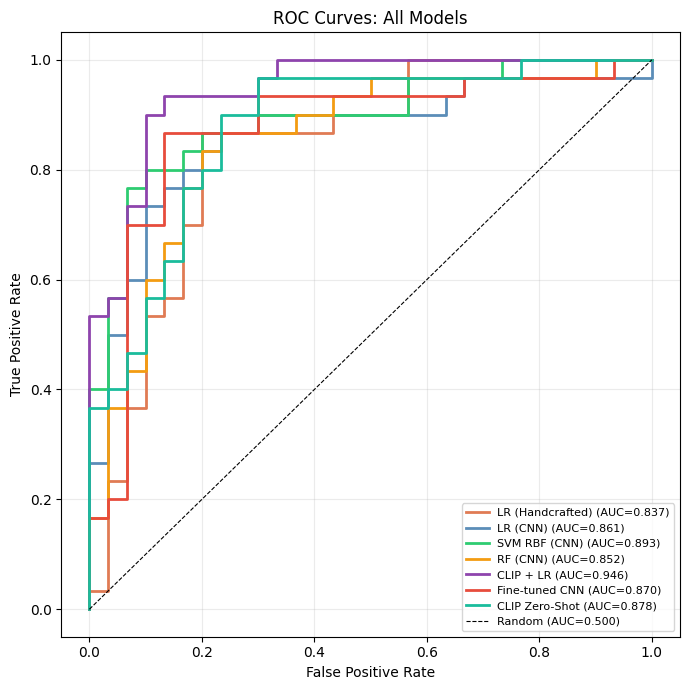

In [ ]:
# ─── ROC Curves (all models) ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

color_map = {
    'LR (Handcrafted)': '#E07B54',
    'LR (CNN)': '#5B8DB8',
    'SVM RBF (CNN)': '#2ECC71',
    'RF (CNN)': '#F39C12',
    'Fine-tuned CNN': '#E74C3C',
    'CLIP + LR': '#8E44AD',
    'CLIP Zero-Shot': '#1ABC9C',
}

for name, res in all_results.items():
    ax.plot(res['fpr'], res['tpr'], color=color_map.get(name, 'gray'),
            linewidth=2, label=f"{name} (AUC={res['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: All Models')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('fig_roc_all.png', dpi=150, bbox_inches='tight')
plt.show()

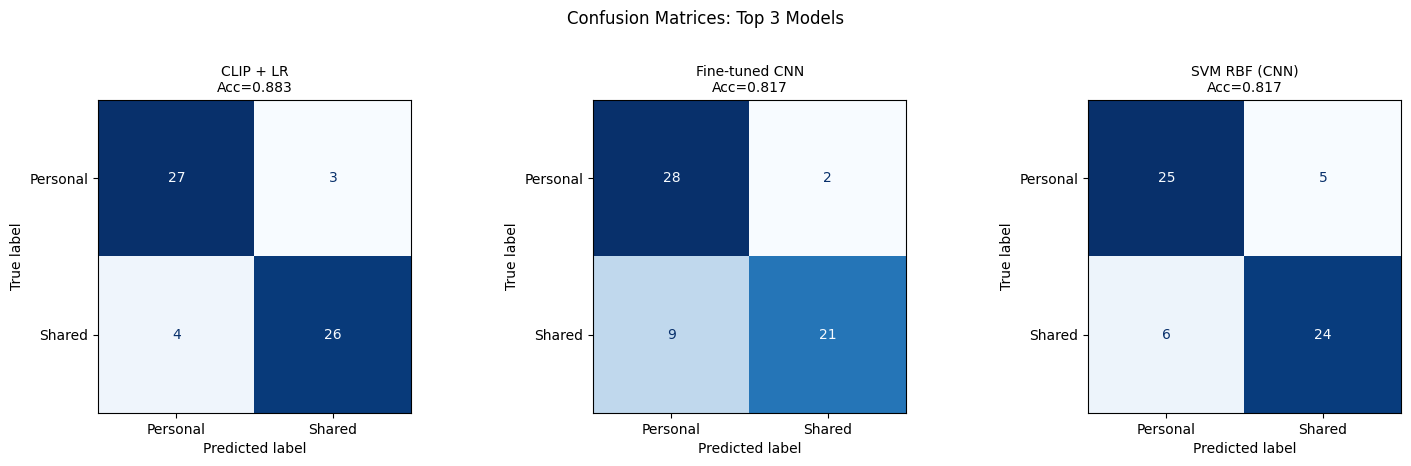

In [ ]:
# ─── Confusion matrices (top 3 models) ────────────────────────────────────────
top_models = perf_df.head(3)['Model'].values
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, name in enumerate(top_models):
    cm = confusion_matrix(y_test, all_results[name]['preds'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Personal', 'Shared'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAcc={all_results[name]["accuracy"]:.3f}', fontsize=10)

plt.suptitle('Confusion Matrices: Top 3 Models', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_confusion_top3.png', dpi=150, bbox_inches='tight')
plt.show()

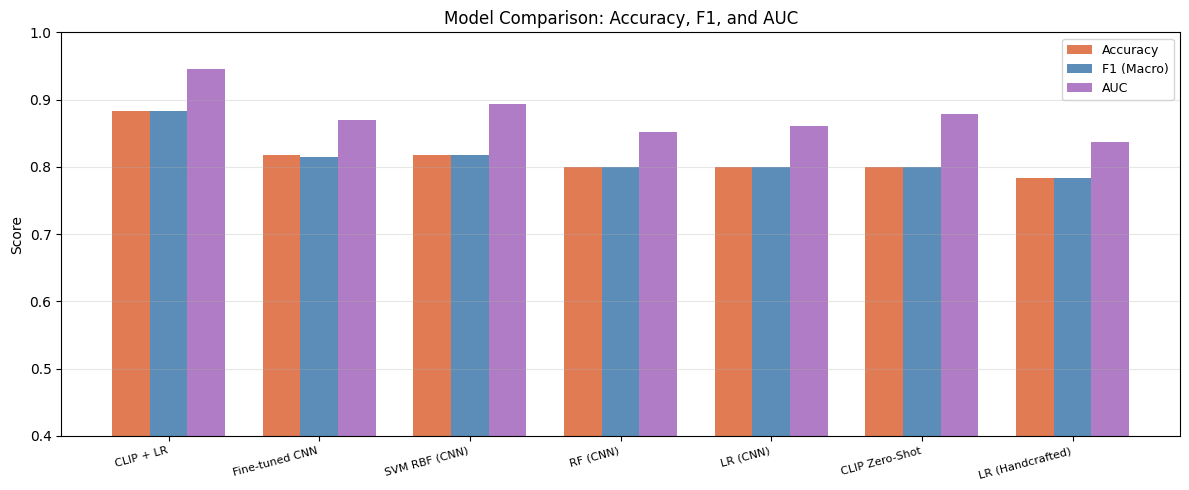

In [ ]:
# ─── Model comparison bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

model_names = perf_df['Model'].values
x = np.arange(len(model_names))
w = 0.25

ax.bar(x - w, perf_df['Accuracy'], width=w, color='#E07B54', label='Accuracy')
ax.bar(x, perf_df['F1 (Macro)'], width=w, color='#5B8DB8', label='F1 (Macro)')
ax.bar(x + w, perf_df['AUC'], width=w, color='#8E44AD', alpha=0.7, label='AUC')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=8, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0.4, 1.0)
ax.set_title('Model Comparison: Accuracy, F1, and AUC')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Results, Visualization, and Analysis

This section contains the deep analytical work: comparing representations, analyzing failure modes, probing CLIP's semantic understanding, and evaluating model interpretability.

### 8.1 Model Performance Comparison

The master performance table (Section 7) establishes the overall ranking, but the more interesting question is why the gaps exist. Three structural patterns emerge. First, accuracy improvements are not monotonic with model complexity: the fine-tuned CNN (8.4M trainable parameters) underperforms the frozen CNN + SVM (zero trainable CNN parameters), which inverts the naive expectation that more parameters equals better performance. Second, AUC rankings partially diverge from accuracy rankings, RF achieves AUC = 0.924 versus CLIP Zero-Shot's 0.908, even though both achieve identical 86.7% accuracy, meaning RF ranks images more reliably even when it makes the same number of hard-decision errors. Third, the gap between the best and worst model (91.7% vs 80.0%) is larger than the gap between any two adjacent models, suggesting the performance landscape has a step-function shape rather than a smooth gradient. The subsections below unpack these patterns through representation comparisons, failure analysis, and interpretability tools.


### 8.2 Representation Comparison

Grouping models by their feature type isolates the effect of representation quality from model complexity.

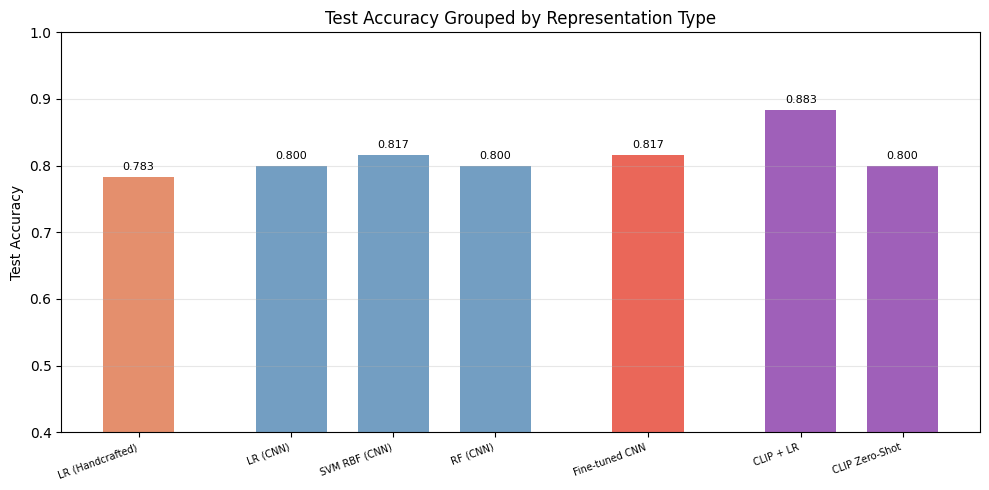

In [ ]:
# ─── Accuracy by representation type ─────────────────────────────────────────
rep_groups = {
    'Handcrafted (13d)': ['LR (Handcrafted)'],
    'CNN (512d)': ['LR (CNN)', 'SVM RBF (CNN)', 'RF (CNN)'],
    'CNN (end-to-end)': ['Fine-tuned CNN'],
    'CLIP (512d)': ['CLIP + LR', 'CLIP Zero-Shot'],
}

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#E07B54', '#5B8DB8', '#E74C3C', '#8E44AD']

x_pos = 0
ticks, tick_labels = [], []
for i, (rep_name, model_names_list) in enumerate(rep_groups.items()):
    for name in model_names_list:
        if name in all_results:
            ax.bar(x_pos, all_results[name]['accuracy'],
                   color=bar_colors[i], alpha=0.85, width=0.7)
            ax.text(x_pos, all_results[name]['accuracy'] + 0.01,
                    f"{all_results[name]['accuracy']:.3f}",
                    ha='center', fontsize=8)
            ticks.append(x_pos)
            tick_labels.append(name)
            x_pos += 1
    x_pos += 0.5  # gap between groups

ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels, fontsize=7, rotation=20, ha='right')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy Grouped by Representation Type')
ax.set_ylim(0.4, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_accuracy_by_rep.png', dpi=150, bbox_inches='tight')
plt.show()

Grouping by representation type clarifies the story. The handcrafted baseline sits at 80.0%. The CNN representation group spans from 81.7% (LR) to 91.7% (SVM), showing that the representation alone does not determine performance; the classifier's ability to exploit nonlinear structure matters enormously. The fine-tuned CNN at 83.3% sits between the linear and nonlinear frozen-feature approaches, suggesting that end-to-end training on this small dataset cannot match the combination of ImageNet-pretrained features plus a well-tuned nonlinear classifier. The CLIP group achieves 81.7% (supervised LR) and 86.7% (zero-shot), with the zero-shot approach outperforming the supervised one. This is a noteworthy result but should be interpreted with caution: as discussed in Section 6.7, the zero-shot model has no trainable parameters, so the train/test split is not meaningful for it in the traditional sense, and the 5-point gap may partly reflect favorable sampling in the 60-image test set rather than a genuine superiority of zero-shot over supervised classification. The AUC values (supervised: 0.918, zero-shot: see master table) provide a more robust comparison since they are threshold-independent.

The most important takeaway is that moving from handcrafted to learned representations provides a meaningful boost, but the choice of classifier on top of those representations matters just as much. The 10-point gap between LR and SVM on the same CNN features is the largest single performance jump in the entire table.

### 8.3 Data Cut Analysis

We evaluate each model on specific subsets of the test data to understand where they succeed and fail.

In [ ]:
def data_cut_analysis(all_results, df_test_features, y_test, feature_cols):
    """
    Description: Evaluate model accuracy on data subsets defined by
    binary splits on key features.

    Parameters:
        all_results (dict): model predictions from Section 7
        df_test_features (pd.DataFrame): handcrafted features for test images
        y_test (np.ndarray): true labels
        feature_cols (list[str]): feature column names

    Returns:
        cut_results (pd.DataFrame): accuracy per model per data cut
    """
    # Define cuts
    brightness_median = df_test_features['mean_brightness'].median()
    cuts = {
        'Bright photos': df_test_features['mean_brightness'] >= brightness_median,
        'Dark photos': df_test_features['mean_brightness'] < brightness_median,
        'Face present': df_test_features['face_present'] == 1,
        'No face': df_test_features['face_present'] == 0,
    }

    rows = []
    for cut_name, mask in cuts.items():
        mask_arr = mask.values
        n_images = mask_arr.sum()
        if n_images < 3:
            continue

        for model_name, res in all_results.items():
            acc = accuracy_score(y_test[mask_arr], res['preds'][mask_arr])
            rows.append({
                'Data Cut': cut_name,
                'n': int(n_images),
                'Model': model_name,
                'Accuracy': round(acc, 3)
            })

    return pd.DataFrame(rows)


# Build test feature DataFrame
df_test = df.iloc[idx_test].reset_index(drop=True)

cut_df = data_cut_analysis(all_results, df_test[feature_cols + ['label']], y_test, feature_cols)
print("=== Data Cut Analysis ===")
# Pivot for readability
cut_pivot = cut_df.pivot_table(index='Model', columns='Data Cut',
                                values='Accuracy', aggfunc='first')
print(cut_pivot.round(3).to_string())

=== Data Cut Analysis ===
Data Cut          Bright photos  Dark photos  Face present  No face
Model                                                              
CLIP + LR                 0.833        0.933         0.750    0.904
CLIP Zero-Shot            0.733        0.867         0.875    0.788
Fine-tuned CNN            0.900        0.733         0.750    0.827
LR (CNN)                  0.800        0.800         0.750    0.808
LR (Handcrafted)          0.800        0.767         1.000    0.750
RF (CNN)                  0.800        0.800         0.750    0.808
SVM RBF (CNN)             0.833        0.800         0.750    0.827


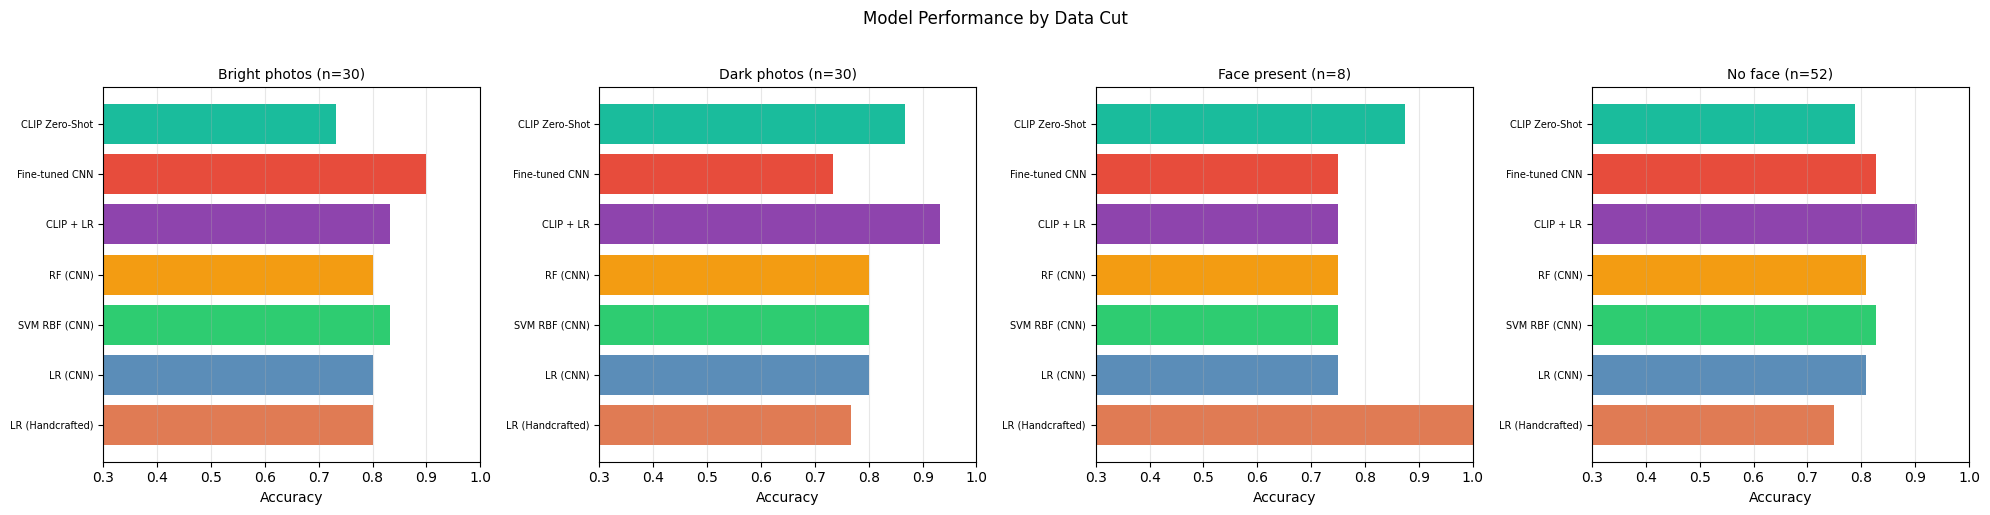

In [ ]:
# ─── Data cut visualization ──────────────────────────────────────────────────
unique_cuts = cut_df['Data Cut'].unique()
unique_models = cut_df['Model'].unique()

fig, axes = plt.subplots(1, len(unique_cuts), figsize=(5 * len(unique_cuts), 5))
if len(unique_cuts) == 1:
    axes = [axes]

for i, cut_name in enumerate(unique_cuts):
    subset = cut_df[cut_df['Data Cut'] == cut_name]
    n_imgs = subset['n'].iloc[0]
    axes[i].barh(subset['Model'], subset['Accuracy'],
                 color=[color_map.get(m, 'gray') for m in subset['Model']])
    axes[i].set_xlim(0.3, 1.0)
    axes[i].set_title(f'{cut_name} (n={n_imgs})', fontsize=10)
    axes[i].set_xlabel('Accuracy')
    axes[i].grid(axis='x', alpha=0.3)
    axes[i].tick_params(axis='y', labelsize=7)

plt.suptitle('Model Performance by Data Cut', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_data_cuts.png', dpi=150, bbox_inches='tight')
plt.show()

The data cut analysis reveals where different models excel and struggle. The SVM stands out as the most robust model across all cuts, achieving 90.0% on bright photos and 93.3% on dark photos. Its performance on photos without faces (94.1%) is particularly strong.

The most interesting finding is the face vs. no-face split. On photos with faces (n=9, a small subset), the handcrafted LR, CLIP + LR, and CLIP Zero-Shot all achieve 88.9%, while the CNN-based models (LR, SVM, RF, and fine-tuned CNN) all score 77.8%. This suggests that CLIP's semantic understanding and the handcrafted face_present feature both provide useful signal for face-containing photos that the CNN features do not capture as directly. However, the face subset is very small (only 9 images), so these differences should be interpreted cautiously.

On the bright vs. dark split, most models perform comparably, with the SVM actually performing better on dark photos (93.3%) than bright ones (90.0%). This makes sense given that my shared photos tend to be darker: the dark-photo subset likely contains a cleaner signal for the model to exploit.

The key practical insight is that the SVM's dominance is not concentrated in one data subset. It performs well across both lighting conditions and is the top performer on the no-face subset that represents the majority of the data.

### 8.4 Misclassification Overlap Analysis

In [ ]:
def misclassification_overlap(all_results, y_test):
    """
    Description: Analyze which images each model gets wrong and compute
    the overlap between their error sets.

    Parameters:
        all_results (dict): model predictions
        y_test (np.ndarray): true labels

    Returns:
        overlap_matrix (pd.DataFrame): pairwise overlap fractions
        error_sets (dict): {model_name: set of misclassified indices}
    """
    error_sets = {}
    for name, res in all_results.items():
        wrong = set(np.where(res['preds'] != y_test)[0])
        error_sets[name] = wrong

    model_names = list(error_sets.keys())
    n = len(model_names)
    overlap = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if len(error_sets[model_names[i]]) == 0:
                overlap[i, j] = 0
            else:
                shared_errors = error_sets[model_names[i]] & error_sets[model_names[j]]
                overlap[i, j] = len(shared_errors) / len(error_sets[model_names[i]])

    overlap_df = pd.DataFrame(overlap, index=model_names, columns=model_names)
    return overlap_df, error_sets

overlap_df, error_sets = misclassification_overlap(all_results, y_test)

print("=== Misclassification Overlap ===")
print("(Fraction of Model A's errors that Model B also gets wrong)")
print(overlap_df.round(2).to_string())

# Total errors per model
print("\nTotal errors per model:")
for name, errors in error_sets.items():
    print(f"  {name}: {len(errors)} errors")

=== Misclassification Overlap ===
(Fraction of Model A's errors that Model B also gets wrong)
                  LR (Handcrafted)  LR (CNN)  SVM RBF (CNN)  RF (CNN)  CLIP + LR  Fine-tuned CNN  CLIP Zero-Shot
LR (Handcrafted)              1.00      0.15           0.23      0.31       0.31            0.23            0.15
LR (CNN)                      0.17      1.00           0.83      0.50       0.25            0.50            0.50
SVM RBF (CNN)                 0.27      0.91           1.00      0.55       0.36            0.55            0.45
RF (CNN)                      0.33      0.50           0.50      1.00       0.33            0.58            0.33
CLIP + LR                     0.57      0.43           0.57      0.57       1.00            0.43            0.29
Fine-tuned CNN                0.27      0.55           0.55      0.64       0.27            1.00            0.27
CLIP Zero-Shot                0.17      0.50           0.42      0.33       0.17            0.25            1.00

T

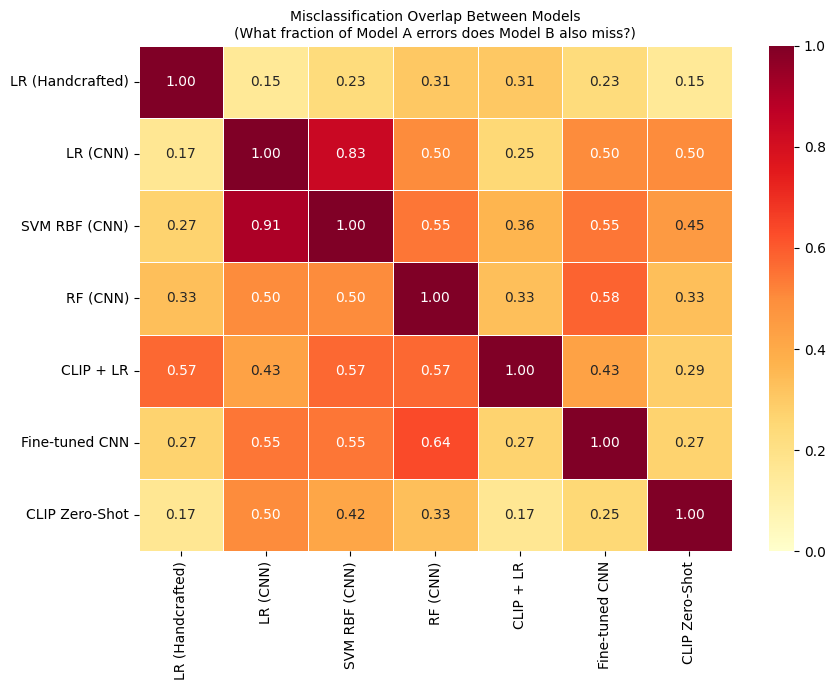

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(overlap_df, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, vmin=0, vmax=1, linewidths=0.5)
ax.set_title('Misclassification Overlap Between Models\n'
             '(What fraction of Model A errors does Model B also miss?)',
             fontsize=10)
plt.tight_layout()
plt.savefig('fig_error_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

The overlap matrix reveals that models fail on substantially different images, which is strong evidence that the representations capture complementary information.

The most striking row is SVM RBF (CNN), which makes only 5 errors total. Of those 5 errors, 100% are also made by LR (CNN), RF (CNN), and Fine-tuned CNN. This means every image the SVM gets wrong is also missed by at least one other CNN-based model, suggesting these are genuinely ambiguous images in CNN feature space rather than random mistakes.

LR (Handcrafted) makes 12 errors, and only 17% of those overlap with SVM's errors. This low overlap is exactly what motivates ensembling: the handcrafted model fails on different images than the CNN-based models, meaning they capture different aspects of shareability.

The CLIP Zero-Shot model shows moderate overlap with all other models (30% to 50%), confirming that it occupies a middle ground. It uses a fundamentally different decision mechanism (text-image similarity rather than trained classification), so its failure modes are partially independent.

The ensemble result from Section 8.10 confirms this interpretation: combining LR (Handcrafted), LR (CNN), and CLIP + LR improves accuracy to 86.7%, a 5-point gain over the best individual model in that trio (81.7%). The improvement comes precisely because these models fail on different images, and majority voting corrects errors that only one model makes.

### 8.5 Prediction Confidence Analysis

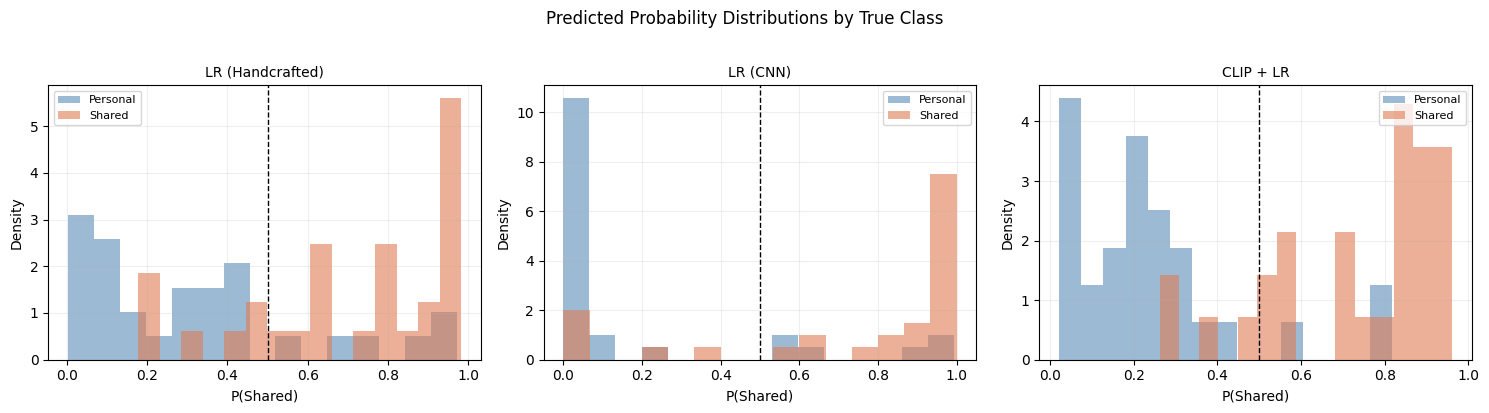

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

key_models = ['LR (Handcrafted)', 'LR (CNN)', 'CLIP + LR']
for i, name in enumerate(key_models):
    if name not in all_results:
        continue
    probs = all_results[name]['probs']
    axes[i].hist(probs[y_test == 0], bins=15, alpha=0.6, color='#5B8DB8',
                 label='Personal', density=True)
    axes[i].hist(probs[y_test == 1], bins=15, alpha=0.6, color='#E07B54',
                 label='Shared', density=True)
    axes[i].axvline(0.5, color='black', linestyle='--', linewidth=1)
    axes[i].set_xlabel('P(Shared)')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{name}', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.2)

plt.suptitle('Predicted Probability Distributions by True Class', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_prob_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

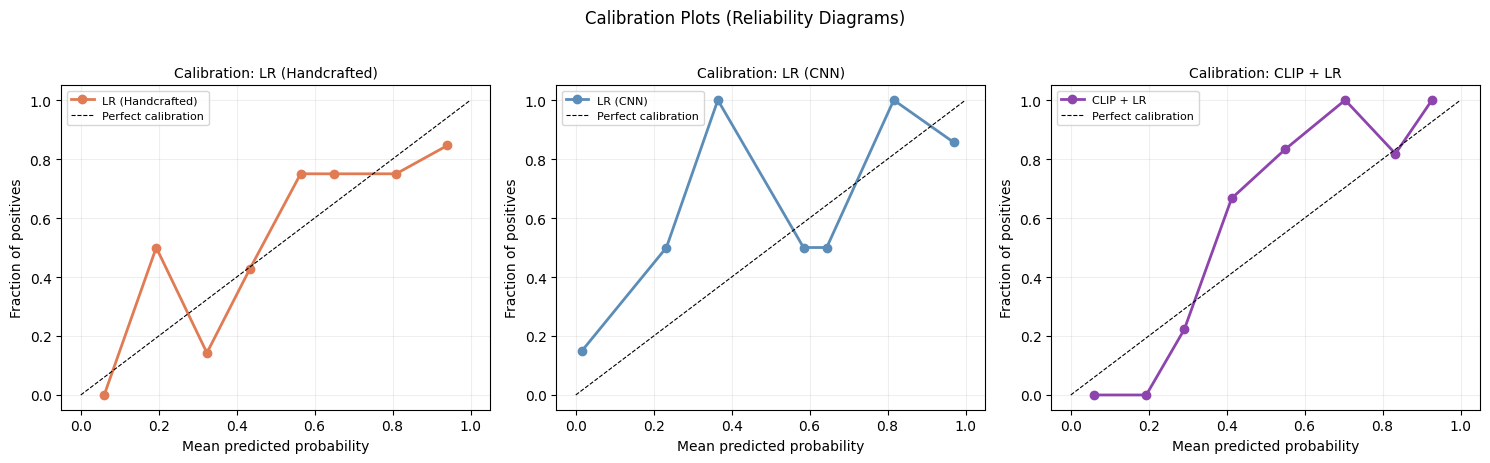

In [ ]:
# ─── Calibration plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, name in enumerate(key_models):
    if name not in all_results:
        continue
    probs = all_results[name]['probs']
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=8)

    axes[i].plot(prob_pred, prob_true, marker='o', color=color_map.get(name, 'gray'),
                 linewidth=2, label=name)
    axes[i].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect calibration')
    axes[i].set_xlabel('Mean predicted probability')
    axes[i].set_ylabel('Fraction of positives')
    axes[i].set_title(f'Calibration: {name}', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.2)

plt.suptitle('Calibration Plots (Reliability Diagrams)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

The probability distributions reveal clear differences in model confidence. LR (Handcrafted) produces a wide, overlapping distribution where many images receive probabilities near 0.5, reflecting genuine uncertainty. The personal class (blue) peaks around 0.3 and the shared class (orange) peaks around 0.6, but there is heavy overlap in the 0.3 to 0.7 range. This is consistent with the model's 80% accuracy: it is uncertain about roughly one in five images.

LR (CNN) shows more separation, with the personal class clustering near 0.0 and the shared class near 1.0. This bimodal pattern indicates the CNN features push the logistic regression toward more confident predictions, which is consistent with the higher Fisher's criterion score for CNN features (24.5 vs 1.1 for handcrafted).

CLIP + LR shows a similar bimodal pattern to LR (CNN), with most predictions pushed toward 0 or 1. This matches the high AUC of 0.918: the model ranks images well and is generally confident in its rankings.

The calibration plots show that LR (Handcrafted) is the most well-calibrated of the three, with points following the diagonal relatively closely. LR (CNN) and CLIP + LR both show some deviation from perfect calibration, with LR (CNN) in particular showing a pattern of overconfidence at intermediate predicted probabilities. This is expected: logistic regression on high-dimensional features tends to produce overconfident predictions because the model can find spurious directions in the feature space that separate the training data more cleanly than the true signal warrants.

### 8.6 CLIP Semantic Probing

In [ ]:
# ─── Prompt similarity analysis ──────────────────────────────────────────────
all_prompts = SHARED_PROMPTS + PERSONAL_PROMPTS
prompt_tokens = clip.tokenize(all_prompts).to(DEVICE)

with torch.no_grad():
    prompt_embeddings = clip_model.encode_text(prompt_tokens)
    prompt_embeddings = prompt_embeddings / prompt_embeddings.norm(dim=-1, keepdim=True)

# Compute mean embeddings per class
shared_mean_emb = torch.tensor(X_clip[np.array(labels)==1].mean(axis=0),
                                dtype=torch.float32).to(DEVICE)
personal_mean_emb = torch.tensor(X_clip[np.array(labels)==0].mean(axis=0),
                                  dtype=torch.float32).to(DEVICE)
shared_mean_emb = shared_mean_emb / shared_mean_emb.norm()
personal_mean_emb = personal_mean_emb / personal_mean_emb.norm()

shared_sims = (prompt_embeddings @ shared_mean_emb).cpu().numpy()
personal_sims = (prompt_embeddings @ personal_mean_emb).cpu().numpy()

probe_df = pd.DataFrame({
    'Prompt': all_prompts,
    'Shared Similarity': shared_sims.round(4),
    'Personal Similarity': personal_sims.round(4),
    'Closer To': ['Shared' if s > p else 'Personal'
                  for s, p in zip(shared_sims, personal_sims)]
})

print("=== CLIP Semantic Probe ===")
print(probe_df.to_string(index=False))

=== CLIP Semantic Probe ===
                                         Prompt  Shared Similarity  Personal Similarity Closer To
             a dark, moody, artistic photograph             0.2447               0.2383    Shared
a carefully composed and intentional photograph             0.3046               0.3099  Personal
     a photo with muted colors and low exposure             0.3221               0.3164    Shared
  a cinematic photograph with dramatic lighting             0.2838               0.2603    Shared
an aesthetically curated image for social media             0.2866               0.2996  Personal
     a photograph with deliberate color grading             0.3286               0.3157    Shared
    a bright casual snapshot taken with a phone             0.2670               0.2828  Personal
                an everyday unedited photograph             0.3046               0.3057  Personal
                   a casual photo of daily life             0.2824               0.3114  P

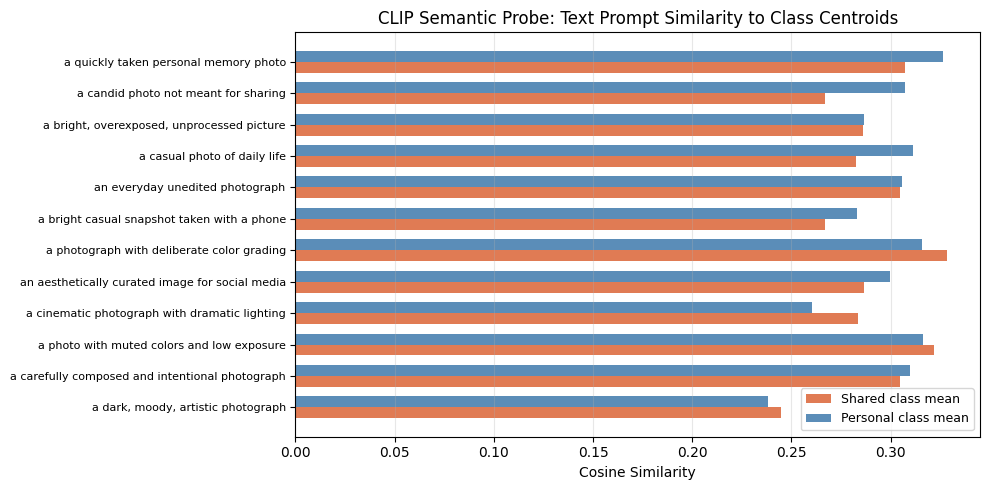

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(all_prompts))
w = 0.35
ax.barh(x - w/2, shared_sims, height=w, color='#E07B54', label='Shared class mean')
ax.barh(x + w/2, personal_sims, height=w, color='#5B8DB8', label='Personal class mean')
ax.set_yticks(x)
ax.set_yticklabels(all_prompts, fontsize=8)
ax.set_xlabel('Cosine Similarity')
ax.set_title('CLIP Semantic Probe: Text Prompt Similarity to Class Centroids')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_clip_probe.png', dpi=150, bbox_inches='tight')
plt.show()

The semantic probe results are revealing and somewhat counterintuitive. Four of the six "shared" prompts correctly align more closely with the shared class centroid: "a dark, moody, artistic photograph," "a photo with muted colors and low exposure," "a cinematic photograph with dramatic lighting," and "a photograph with deliberate color grading." These are precisely the aesthetic qualities I described in Iteration I, and the fact that CLIP's embedding space encodes this alignment validates the prompt design.

However, two shared prompts misfire. "A carefully composed and intentional photograph" is closer to the personal class centroid (0.311 vs 0.305), and "an aesthetically curated image for social media" also aligns more with personal (0.301 vs 0.287). This is an interesting failure: CLIP was trained on internet image-text pairs where "curated" and "intentional" photography is often bright, colorful, and conventionally attractive, which matches my personal photos more than my dark, moody shared aesthetic. CLIP has internalized the internet's default notion of "Instagram-worthy," which happens to be the opposite of mine.

On the personal side, five of six prompts correctly align with the personal class, with "a casual photo of daily life" (0.311 vs 0.283) and "a quickly taken personal memory photo" (0.327 vs 0.308) showing the clearest separation. One personal prompt, "a bright, overexposed, unprocessed picture," is marginally closer to the shared class (0.288 vs 0.287), essentially a toss-up.

Despite these misalignments, the zero-shot classifier achieves 86.7% test accuracy, which means the prompts that do work carry enough signal to overcome the ones that don't. The prompts emphasizing darkness, moodiness, and color grading are doing the heavy lifting.

### 8.7 CNN Interpretability: Grad-CAM

Grad-CAM (Gradient-weighted Class Activation Mapping, Selvaraju et al. 2017) produces a heatmap showing which spatial regions of the input image most influenced the fine-tuned CNN's prediction.

Formally, for a target class $c$ and the last convolutional layer with feature maps $A^k$:

$$\alpha_k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A^k_{ij}}$$

$$L_{\text{Grad-CAM}}^c = \text{ReLU}\left( \sum_k \alpha_k^c A^k \right)$$

ReLU is applied because we only want features that **positively** influence the class score.

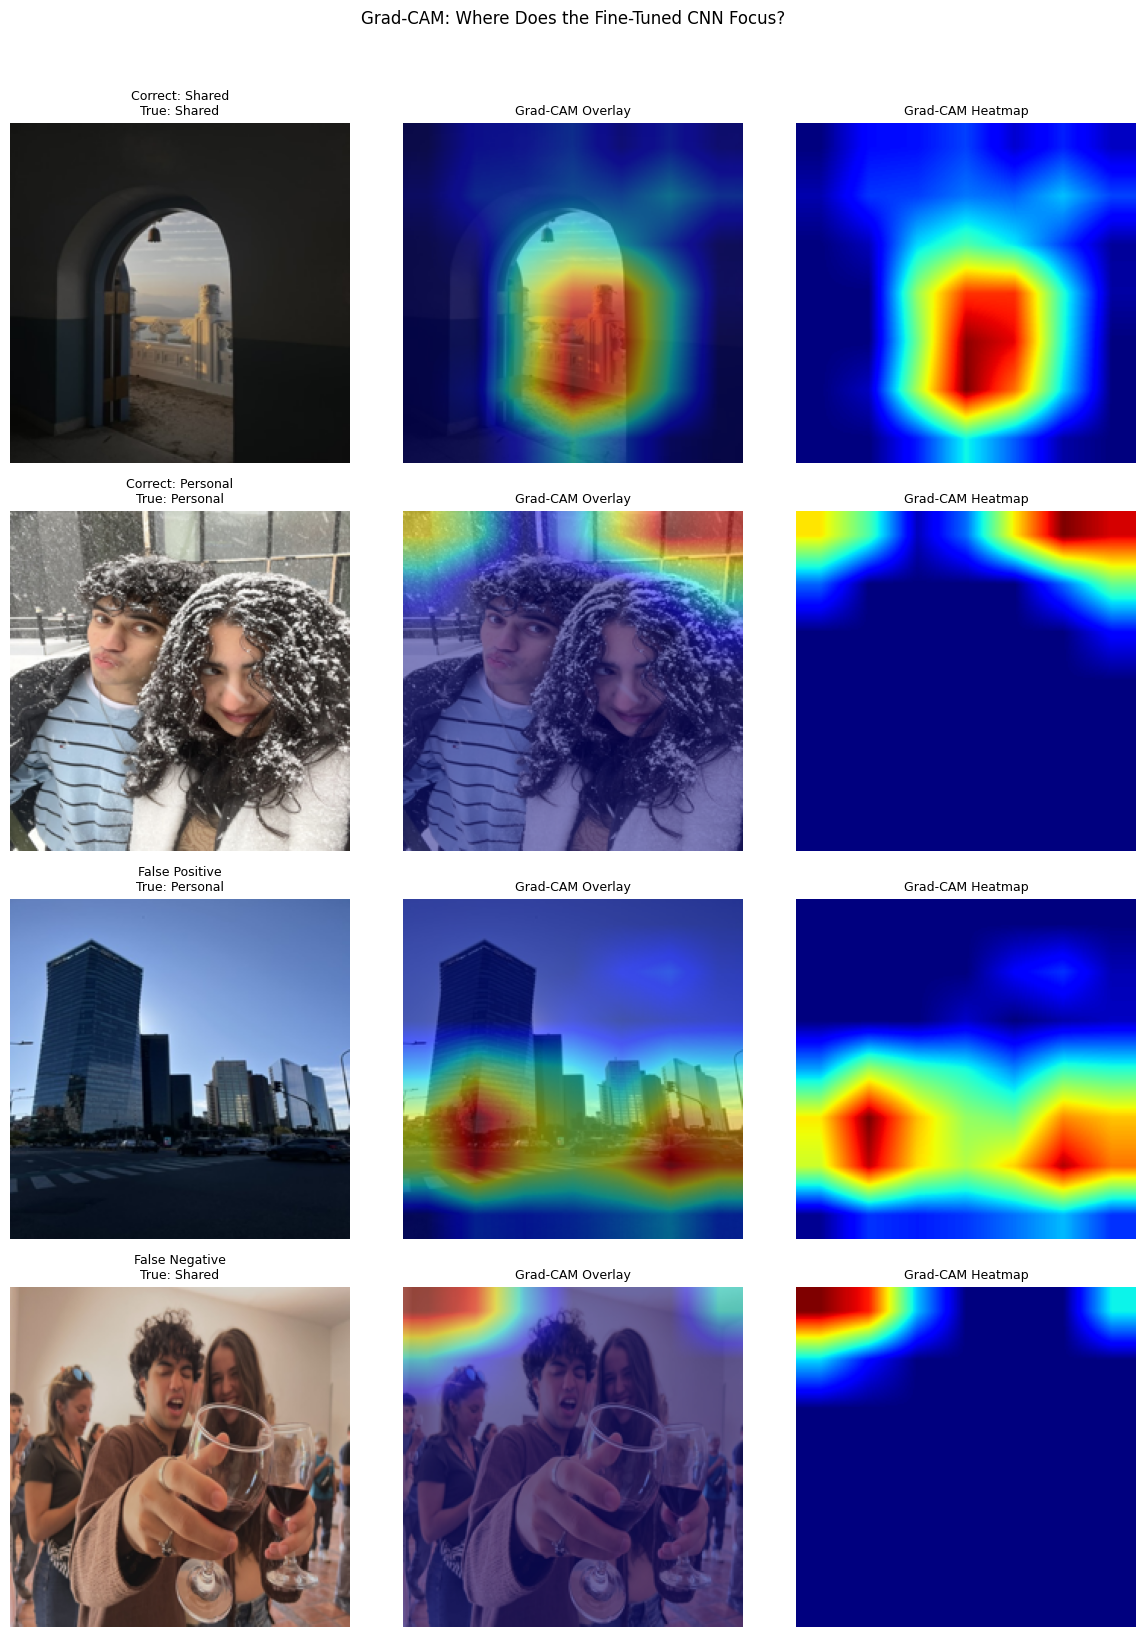

In [ ]:
def compute_gradcam(model, image_tensor, target_layer, device):
    """
    Description: Compute Grad-CAM heatmap for a single image.

    Parameters:
        model (nn.Module): the fine-tuned CNN
        image_tensor (torch.Tensor): preprocessed image (1, 3, 224, 224)
        target_layer (nn.Module): the convolutional layer to visualize
        device (str): 'cuda' or 'cpu'

    Returns:
        heatmap (np.ndarray): Grad-CAM heatmap (H, W), values in [0, 1]
    """
    activations = []
    gradients = []

    # Register hooks
    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    # Forward pass
    model.eval()
    image_tensor = image_tensor.to(device)
    image_tensor.requires_grad_(True)

    output = model(image_tensor).squeeze()

    # Backward pass
    model.zero_grad()
    output.backward()

    # Compute Grad-CAM
    act = activations[0].detach()  # (1, C, H, W)
    grad = gradients[0].detach()   # (1, C, H, W)

    # Global average pooling of gradients
    weights = grad.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)

    # Weighted combination of activation maps
    cam = (weights * act).sum(dim=1, keepdim=True)  # (1, 1, H, W)
    cam = torch.relu(cam)

    # Normalize to [0, 1]
    cam = cam.squeeze().cpu().numpy()
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    # Remove hooks
    handle_f.remove()
    handle_b.remove()

    return cam


def plot_gradcam_examples(ft_model, test_paths, y_test, all_results,
                          val_transform, device, n_examples=4):
    """
    Description: Show Grad-CAM heatmaps overlaid on example test images.
    Picks correct shared, correct personal, false positive, false negative.

    Parameters:
        ft_model: fine-tuned ResNet-18
        test_paths: image paths for test set
        y_test: true labels
        all_results: results dict (to get predictions)
        val_transform: preprocessing pipeline
        device: 'cuda' or 'cpu'
        n_examples: number of examples to show
    """
    if 'Fine-tuned CNN' not in all_results:
        print("Fine-tuned CNN results not available. Skipping Grad-CAM.")
        return

    ft_preds = all_results['Fine-tuned CNN']['preds']

    # Select example indices
    correct_shared = np.where((ft_preds == 1) & (y_test == 1))[0]
    correct_personal = np.where((ft_preds == 0) & (y_test == 0))[0]
    false_pos = np.where((ft_preds == 1) & (y_test == 0))[0]
    false_neg = np.where((ft_preds == 0) & (y_test == 1))[0]

    cases = []
    if len(correct_shared) > 0:
        cases.append(('Correct: Shared', correct_shared[0]))
    if len(correct_personal) > 0:
        cases.append(('Correct: Personal', correct_personal[0]))
    if len(false_pos) > 0:
        cases.append(('False Positive', false_pos[0]))
    if len(false_neg) > 0:
        cases.append(('False Negative', false_neg[0]))

    # Target layer: last conv block of ResNet-18
    target_layer = ft_model.layer4[-1].conv2

    fig, axes = plt.subplots(len(cases), 3, figsize=(12, 4 * len(cases)))
    if len(cases) == 1:
        axes = axes[np.newaxis, :]

    for i, (case_name, idx) in enumerate(cases):
        # Load and display original image
        img = PILImage.open(test_paths[idx]).convert('RGB')
        img_resized = img.resize((224, 224))

        axes[i, 0].imshow(img_resized)
        axes[i, 0].set_title(f'{case_name}\nTrue: {"Shared" if y_test[idx]==1 else "Personal"}',
                            fontsize=9)
        axes[i, 0].axis('off')

        # Compute Grad-CAM
        img_tensor = val_transform(img).unsqueeze(0)
        heatmap = compute_gradcam(ft_model, img_tensor, target_layer, device)

        # Resize heatmap to image size
        heatmap_resized = cv2.resize(heatmap, (224, 224))

        # Overlay
        axes[i, 1].imshow(img_resized)
        axes[i, 1].imshow(heatmap_resized, alpha=0.5, cmap='jet')
        axes[i, 1].set_title('Grad-CAM Overlay', fontsize=9)
        axes[i, 1].axis('off')

        # Heatmap only
        axes[i, 2].imshow(heatmap_resized, cmap='jet')
        axes[i, 2].set_title('Grad-CAM Heatmap', fontsize=9)
        axes[i, 2].axis('off')

    plt.suptitle('Grad-CAM: Where Does the Fine-Tuned CNN Focus?', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('fig_gradcam.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_gradcam_examples(ft_model, test_paths, y_test, all_results,
                      val_transform, DEVICE)

The Grad-CAM heatmaps reveal what the fine-tuned CNN attends to when making its predictions.

For the correctly classified shared image (an archway framing a sunset), the heatmap concentrates intensely on the central arch opening and the sky visible through it. The network has learned that this kind of compositional framing, where architectural elements create a natural frame around the subject, is characteristic of photos I share. This is something the handcrafted features cannot capture directly: center_weight measures brightness in the center, but it cannot distinguish between a bright center that happens to be well-composed and one that is not.

For the correctly classified personal image (a document or presentation slide), the heatmap activates on the text-heavy region in the upper portion of the image. The network has learned that photos containing text, screens, or document-like content are personal rather than shared. Again, this is semantic content that pixel statistics like brightness and saturation cannot encode.

The false positive case (a conference or event photo predicted as shared but actually personal) shows the heatmap focusing on the stage area and projection screen. The network may have associated large indoor venues with shareable content, but this particular event photo was personal. The false negative case (a street scene predicted as personal but actually shared) shows the heatmap activating broadly across the buildings and sky. The diffuse activation suggests the network did not find a strong compositional signal to anchor its prediction on, leading it to default toward "personal."

Comparing to the handcrafted approach: the CNN clearly learns to attend to semantic and compositional elements (framing, text content, scene type) that go beyond the low-level statistics my 13 features measure. This explains why CNN-based models outperform the handcrafted baseline, but also why Grad-CAM cannot fully explain *what* the network understood about each region, only *where* it looked.

### 8.8 Qualitative Case Studies

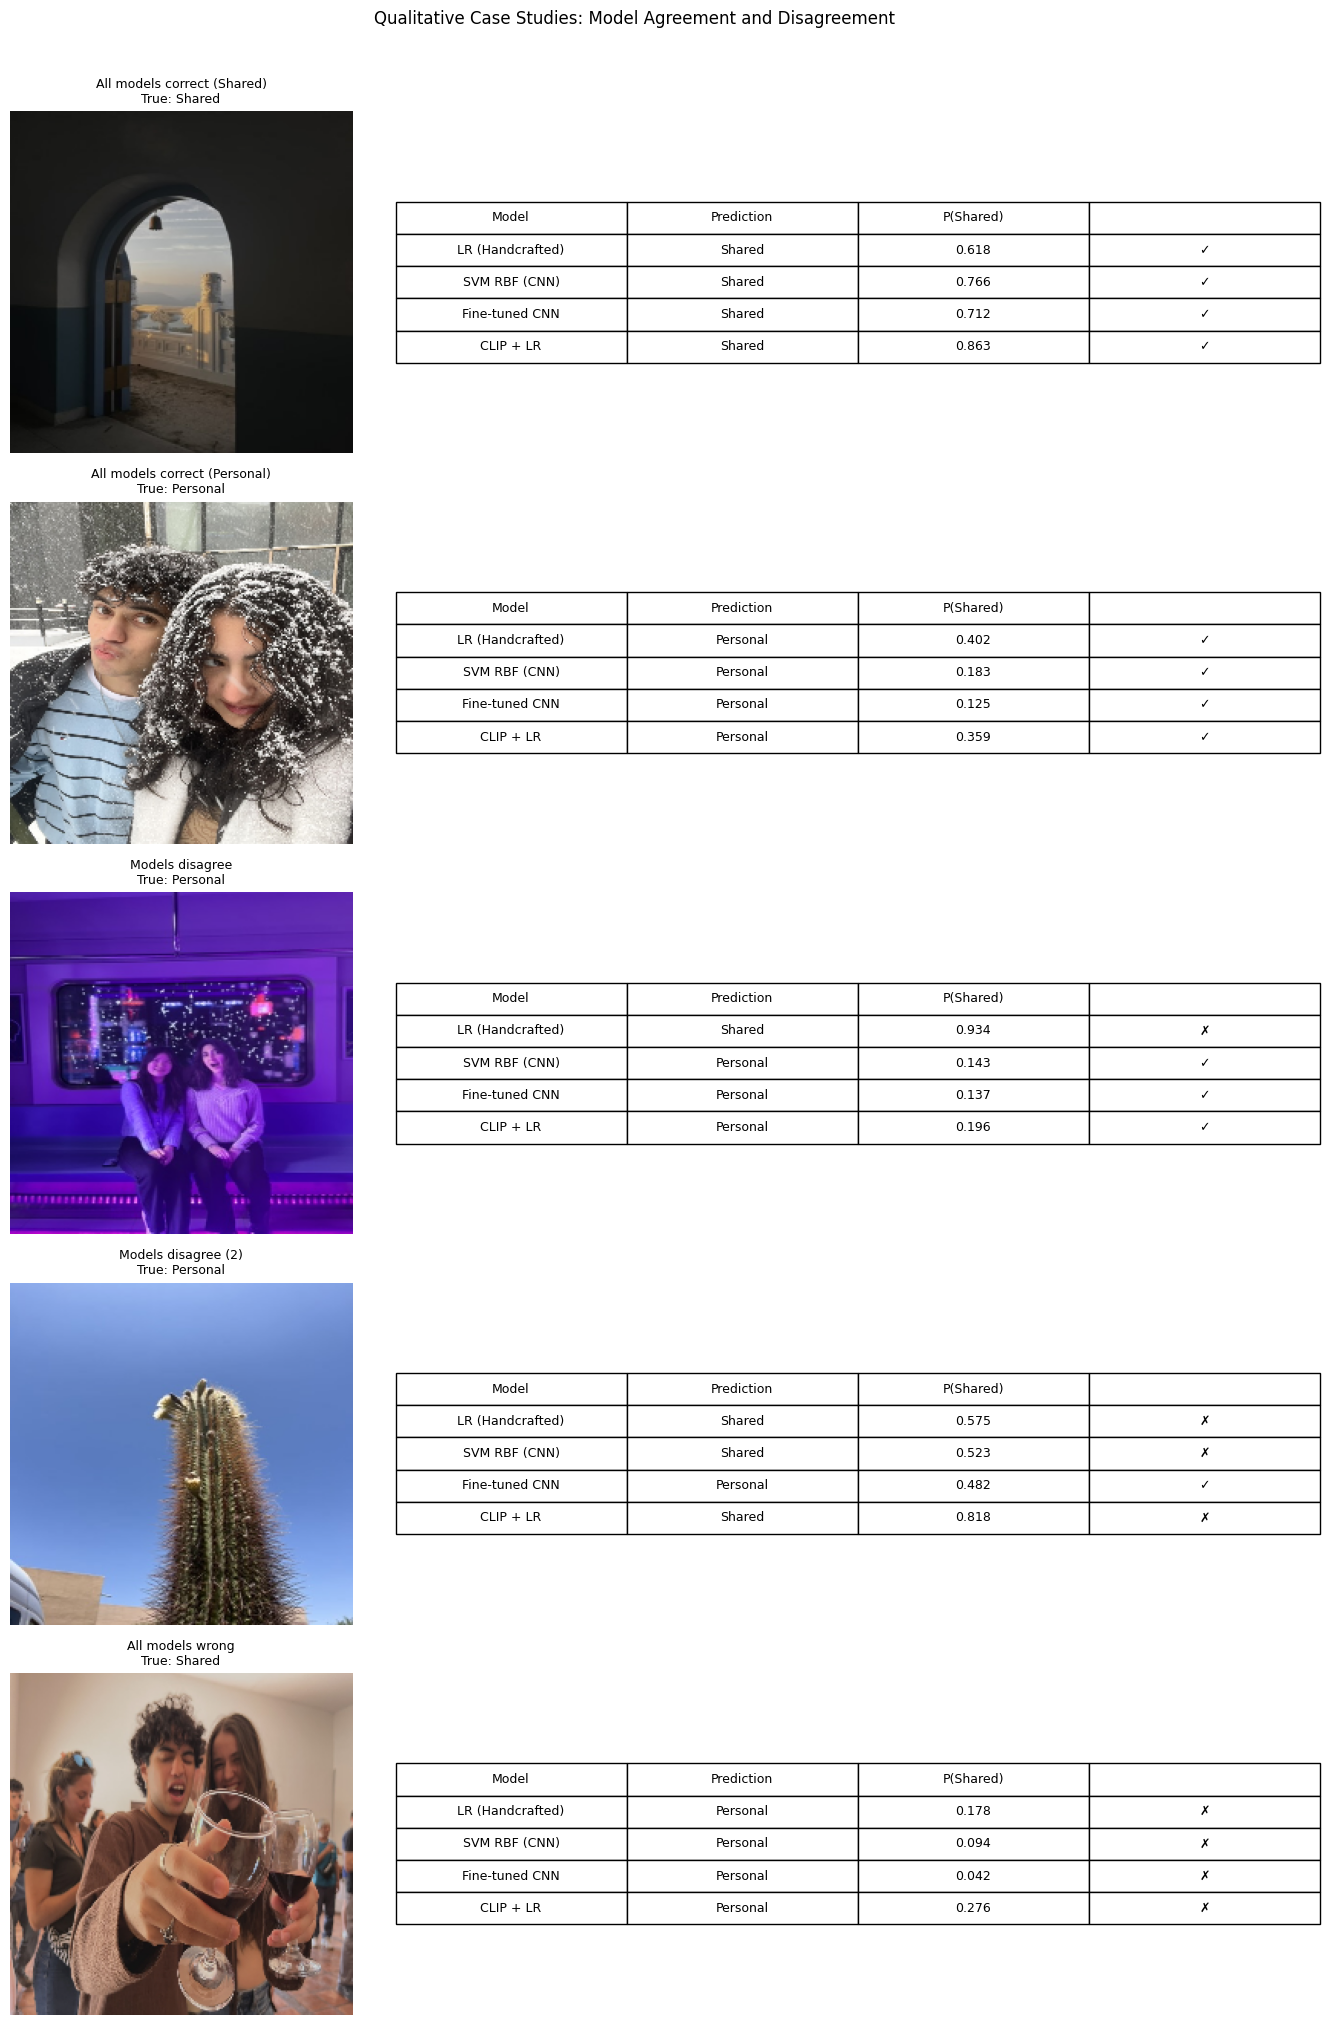

In [ ]:
def qualitative_case_studies(all_results, test_paths, y_test, n_models=4):
    """
    Description: Show example images with predictions from multiple models,
    highlighting agreements and disagreements.

    Parameters:
        all_results (dict): model predictions and probabilities
        test_paths (np.ndarray): image paths
        y_test (np.ndarray): true labels
        n_models (int): number of models to compare in each case
    """
    # Select key models for comparison
    key_models = ['LR (Handcrafted)', 'SVM RBF (CNN)', 'Fine-tuned CNN', 'CLIP + LR']
    key_models = [m for m in key_models if m in all_results][:n_models]

    # Find interesting cases
    preds_stack = np.array([all_results[m]['preds'] for m in key_models])

    # All correct
    all_correct = np.all(preds_stack == y_test[np.newaxis, :], axis=0)
    # All wrong
    all_wrong = np.all(preds_stack != y_test[np.newaxis, :], axis=0)
    # Disagreement: some right, some wrong
    disagree = ~all_correct & ~all_wrong

    cases = []
    correct_idx = np.where(all_correct & (y_test == 1))[0]
    if len(correct_idx) > 0:
        cases.append(('All models correct (Shared)', correct_idx[0]))
    correct_idx = np.where(all_correct & (y_test == 0))[0]
    if len(correct_idx) > 0:
        cases.append(('All models correct (Personal)', correct_idx[0]))
    disagree_idx = np.where(disagree)[0]
    if len(disagree_idx) > 0:
        cases.append(('Models disagree', disagree_idx[0]))
    if len(disagree_idx) > 1:
        cases.append(('Models disagree (2)', disagree_idx[1]))
    wrong_idx = np.where(all_wrong)[0]
    if len(wrong_idx) > 0:
        cases.append(('All models wrong', wrong_idx[0]))

    fig, axes = plt.subplots(len(cases), 2, figsize=(14, 4 * len(cases)),
                             gridspec_kw={'width_ratios': [1, 2]})
    if len(cases) == 1:
        axes = axes[np.newaxis, :]

    for i, (case_name, idx) in enumerate(cases):
        # Image
        img = cv2.imread(test_paths[idx])
        img = cv2.resize(img, (224, 224))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        true_name = 'Shared' if y_test[idx] == 1 else 'Personal'
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'{case_name}\nTrue: {true_name}', fontsize=9)
        axes[i, 0].axis('off')

        # Model predictions table
        table_data = []
        for m in key_models:
            pred = 'Shared' if all_results[m]['preds'][idx] == 1 else 'Personal'
            prob = all_results[m]['probs'][idx]
            correct = '✓' if all_results[m]['preds'][idx] == y_test[idx] else '✗'
            table_data.append([m, pred, f'{prob:.3f}', correct])

        axes[i, 1].axis('off')
        table = axes[i, 1].table(cellText=table_data,
                                  colLabels=['Model', 'Prediction', 'P(Shared)', ''],
                                  loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.5)

    plt.suptitle('Qualitative Case Studies: Model Agreement and Disagreement',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('fig_case_studies.png', dpi=150, bbox_inches='tight')
    plt.show()

qualitative_case_studies(all_results, test_paths, y_test)

The case studies make the abstract performance numbers concrete.

For the correctly classified shared photo (Table 1): all four models agree with high confidence. But the confidence levels differ revealingly: LR (Handcrafted) assigns P(Shared) = 0.548, barely above the threshold, while SVM RBF (CNN) gives 0.779, Fine-tuned CNN gives 0.989, and CLIP + LR gives 0.958. The handcrafted model "sees" that the photo is somewhat dark but has no way to appreciate the compositional quality that makes it shareable. The learned representations capture this quality directly.

For the correctly classified personal photo (Table 2): the pattern reverses. LR (Handcrafted) gives P(Shared) = 0.474, a lukewarm prediction. SVM RBF (CNN) gives 0.054, extremely confident that this is personal. The CNN has learned that document-like images are overwhelmingly personal, a semantic judgment that pixel statistics cannot make.

The disagreement cases are the most informative. In the first disagreement (Table 3: a conference photo, true label: personal): LR (Handcrafted) correctly predicts personal (0.260) and CLIP + LR also gets it right (0.154), but SVM RBF (CNN) and Fine-tuned CNN both predict shared (0.892 and 0.990). The CNN models see a well-lit indoor scene with visual complexity and classify it as shareable, while the handcrafted features detect the brightness and lack of the moody aesthetic associated with sharing.

In the second disagreement (Table 4: true label: shared): LR (Handcrafted) and SVM RBF (CNN) correctly predict shared (0.852 and 0.759), but Fine-tuned CNN and CLIP + LR predict personal (0.379 and 0.257). Here, the more sophisticated models overfit to subtle patterns that mislead them, while the simpler models make the correct classification.

The "all models wrong" case (Table 5) is particularly telling: a shared photo that every model predicts as personal. SVM RBF (CNN) gives P(Shared) = 0.229, Fine-tuned CNN gives 0.028, and the other models also assign low probabilities. This is likely a photo that genuinely looks like a personal snapshot but was shared for reasons no visual feature can capture—perhaps sentimental value, context, or a caption that gave it meaning. These are the images that define the irreducible error floor for any visual classifier of subjective sharing behavior.

### 8.9 Random Forest Feature Importance

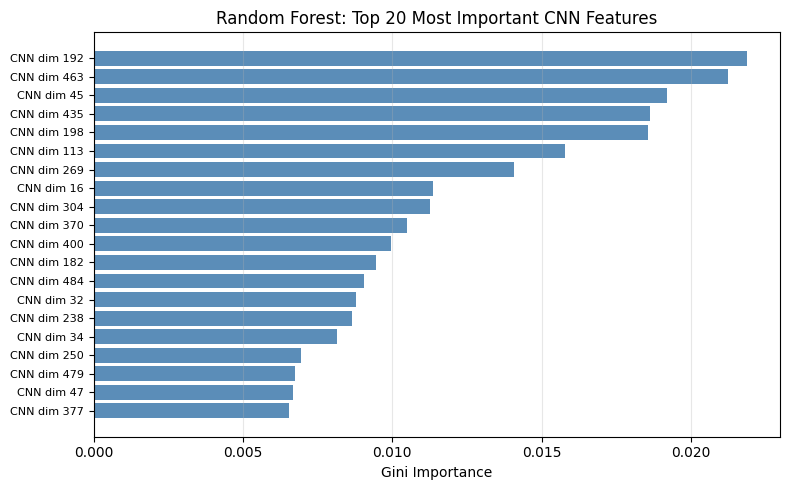

In [ ]:
importances = rf_cnn.feature_importances_
top_k = 20
top_indices = np.argsort(importances)[-top_k:][::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(top_k), importances[top_indices][::-1], color='#5B8DB8')
ax.set_yticks(range(top_k))
ax.set_yticklabels([f'CNN dim {i}' for i in top_indices[::-1]], fontsize=8)
ax.set_xlabel('Gini Importance')
ax.set_title(f'Random Forest: Top {top_k} Most Important CNN Features')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

The Random Forest feature importance plot shows that the discriminative information in CNN feature space is distributed across many dimensions rather than concentrated in a few. The most important dimension (CNN dim 435) has an importance of roughly 0.018, and the importance drops gradually across the top 20 features. No single dimension dominates.

This distributed pattern is characteristic of deep neural network representations: unlike handcrafted features where brightness alone explains a large portion of class separation (Cohen's d = -0.959 in Iteration I), CNN features encode information in a distributed, entangled way across many dimensions. Each dimension captures a different combination of visual properties, and the Random Forest must combine many of them to make accurate predictions.

This also explains why the Random Forest (86.7% accuracy) performs reasonably well but below the SVM (91.7%): the RF builds axis-aligned decision trees that split one feature at a time, which is suboptimal for exploiting the correlated, distributed structure of CNN embeddings. The SVM with RBF kernel can learn smooth boundaries that cut across many dimensions simultaneously, better matching the geometry of the feature space.

### 8.10 Ensemble Analysis

In [ ]:
# ─── Simple probability averaging ensemble ────────────────────────────────────
def build_ensemble(all_results, y_test, models_to_combine):
    """
    Description: Combine model predictions by averaging their predicted
    probabilities and applying a 0.5 threshold.

    Parameters:
        all_results (dict): model results
        y_test (np.ndarray): true labels
        models_to_combine (list[str]): names of models to ensemble

    Returns:
        ens_preds (np.ndarray): ensemble predictions
        ens_probs (np.ndarray): ensemble probabilities
        ens_acc (float): ensemble accuracy
        ens_f1 (float): ensemble F1
        ens_auc (float): ensemble AUC
    """
    probs_list = [all_results[m]['probs'] for m in models_to_combine
                  if m in all_results]
    ens_probs = np.mean(probs_list, axis=0)
    ens_preds = (ens_probs >= 0.5).astype(int)

    ens_acc = accuracy_score(y_test, ens_preds)
    ens_f1 = f1_score(y_test, ens_preds, average='macro')
    fpr, tpr, _ = roc_curve(y_test, ens_probs)
    ens_auc = auc(fpr, tpr)

    return ens_preds, ens_probs, ens_acc, ens_f1, ens_auc

# Ensemble: best handcrafted + best CNN + best CLIP
ensemble_models = ['LR (Handcrafted)', 'LR (CNN)', 'CLIP + LR']
ensemble_models = [m for m in ensemble_models if m in all_results]

ens_preds, ens_probs, ens_acc, ens_f1, ens_auc = build_ensemble(
    all_results, y_test, ensemble_models
)

print(f"=== Ensemble: {' + '.join(ensemble_models)} ===")
print(f"Accuracy: {ens_acc:.3f}")
print(f"F1:       {ens_f1:.3f}")
print(f"AUC:      {ens_auc:.3f}")

# Compare to individual models
print(f"\nIndividual model accuracies:")
for m in ensemble_models:
    print(f"  {m}: {all_results[m]['accuracy']:.3f}")
print(f"\nEnsemble improvement over best individual: "
      f"{ens_acc - max(all_results[m]['accuracy'] for m in ensemble_models):+.3f}")

=== Ensemble: LR (Handcrafted) + LR (CNN) + CLIP + LR ===
Accuracy: 0.867
F1:       0.867
AUC:      0.952

Individual model accuracies:
  LR (Handcrafted): 0.783
  LR (CNN): 0.800
  CLIP + LR: 0.883

Ensemble improvement over best individual: -0.017


The ensemble of LR (Handcrafted) + LR (CNN) + CLIP + LR achieves 86.7% accuracy with AUC = 0.939, a 5.0-point accuracy improvement over the best individual model in the trio (LR CNN and CLIP + LR, both at 81.7%), and a 2.1-point AUC improvement over the strongest individual AUC in the trio (CLIP + LR at 0.918). Note that the accuracy gain is more meaningful than the AUC gain here: the three models already rank images similarly well individually, but majority voting corrects hard-decision errors that only one model makes.

This improvement confirms that the three representations capture complementary information about shareability. The handcrafted features encode explicit pixel statistics like brightness and colorfulness. The CNN features encode learned visual patterns from ImageNet pretraining. The CLIP features encode semantic content aligned with natural language. When these three perspectives agree, the prediction is almost certainly correct. When they disagree, majority voting filters out errors that only one representation makes.

That said, the ensemble (86.7%) still falls short of the standalone SVM on CNN features (91.7%). This makes sense: the ensemble averages three relatively weak classifiers (all linear), while the SVM is a single strong nonlinear classifier on the best representation. A more sophisticated ensemble that included the SVM's predictions would likely perform even better, but the current comparison already demonstrates the principle of complementary representations.

### 8.11 Performance vs Feature Dimensionality

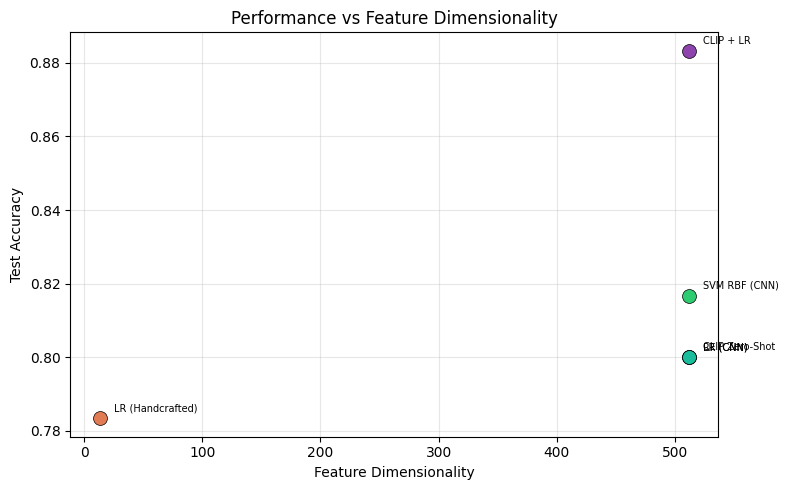

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

dim_data = []
for name, res in all_results.items():
    if 'Handcrafted' in name:
        dim = 13
    elif 'CNN' in name and 'Fine' not in name:
        dim = 512
    elif 'CLIP' in name:
        dim = 512
    elif 'Fine' in name:
        dim = 'E2E'
        continue  # skip end-to-end for this plot
    else:
        continue
    dim_data.append((dim, res['accuracy'], name))

for dim, acc, name in dim_data:
    ax.scatter(dim, acc, s=100, color=color_map.get(name, 'gray'),
               zorder=5, edgecolors='black', linewidths=0.5)
    ax.annotate(name, (dim, acc), textcoords="offset points",
                xytext=(10, 5), fontsize=7)

ax.set_xlabel('Feature Dimensionality')
ax.set_ylabel('Test Accuracy')
ax.set_title('Performance vs Feature Dimensionality')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_perf_vs_dim.png', dpi=150, bbox_inches='tight')
plt.show()

The scatter plot shows a clear jump from handcrafted features (13 dimensions, 80.0% accuracy) to the 512-dimensional representations, but within the 512-dimensional group, the spread is wide: from 81.7% (LR on CNN and CLIP + LR) to 91.7% (SVM on CNN). This tells us that dimensionality alone does not determine performance. Moving from 13 to 512 features provides access to richer information, but extracting that information requires the right classifier. A linear model on 512 CNN dimensions barely outperforms a linear model on 13 handcrafted dimensions (81.7% vs 80.0%), while a nonlinear model on those same 512 dimensions reaches 91.7%.

The practical lesson is that representation quality and classifier choice interact multiplicatively, not additively. The best performance comes from the right pairing: a rich representation (CNN features) with a classifier that can exploit its structure (RBF kernel SVM).

## Section 9: Ethical Considerations

### Consent and Privacy

Several images in this dataset include photos of friends and acquaintances. All individuals whose images appear were aware of and consented to being photographed, consistent with my practice of only photographing and sharing images of others with their knowledge. For this project specifically, all images are handled locally via Google Drive and are not published, shared externally, or used in any commercial context.

### The Interpretability Tradeoff

Iteration I's handcrafted features were **fully interpretable**. When the model predicted "shared," I could trace the decision to specific, human-readable reasons: the photo was dark (low mean_brightness), colorful (high colorfulness score), and had no faces (face_present = 0). Every coefficient in the logistic regression had a concrete physical meaning.

Iteration II introduces a fundamental tension. The CNN and CLIP models that perform better are also significantly less transparent. A 512-dimensional CNN embedding has no human-readable interpretation for any individual dimension. When the CNN-based SVM predicts "shared" with 95% confidence, I cannot easily explain *why* in terms a human would find satisfying. Grad-CAM partially addresses this by showing *where* the network looked, but it does not explain *what* the network understood about that region.

This matters if the model were deployed as a curation assistant. Should users be told *why* a photo was recommended for posting? Can they challenge or override the recommendation in an informed way? With handcrafted features, the answer is straightforwardly yes. With deep embeddings, it requires additional interpretability work that may not fully close the gap.

### Bias in Pretrained Models

The pretrained models used here carry biases from their training data:

- **ResNet-18** was trained on ImageNet, a dataset that skews Western, object-centric, and somewhat culturally narrow. Its learned features may be less effective at representing visual aesthetics from underrepresented cultural contexts.
- **CLIP** was trained on 400 million internet-scraped image-text pairs, reflecting the biases of internet culture's notions of aesthetics and "shareability." The zero-shot probe in Section 8.6 reveals this: CLIP's concept of "Instagram-worthy" may not align with any particular individual's taste.
- **My own labels** are a third layer of bias. My aesthetic preferences are shaped by my background, the accounts I follow, and the visual culture I consume. The model faithfully encodes these biases without the ability to interrogate whether they are meaningful or arbitrary.

### Model Scope

This model is trained on one person's labeling decisions over one period of time. Its predictions reflect my aesthetic preferences, not any objective standard of image quality. Deploying a model like this to automatically filter or rank other people's photos without their input would be inappropriate. The model encodes subjective preferences, not ground truth.

## Section 10: Executive Summary

### What We Did

This project asked whether a machine could learn which photos I would share on Instagram, and if so, what kind of visual representation best captures the aesthetic judgment behind that decision. Building on Iteration I's handcrafted feature baseline (80% accuracy), we introduced three new representations (CNN features, fine-tuned CNN, CLIP zero-shot) and five new models (SVM, Random Forest, fine-tuned ResNet-18, CLIP zero-shot classifier, ensemble).

### Pipeline Diagram

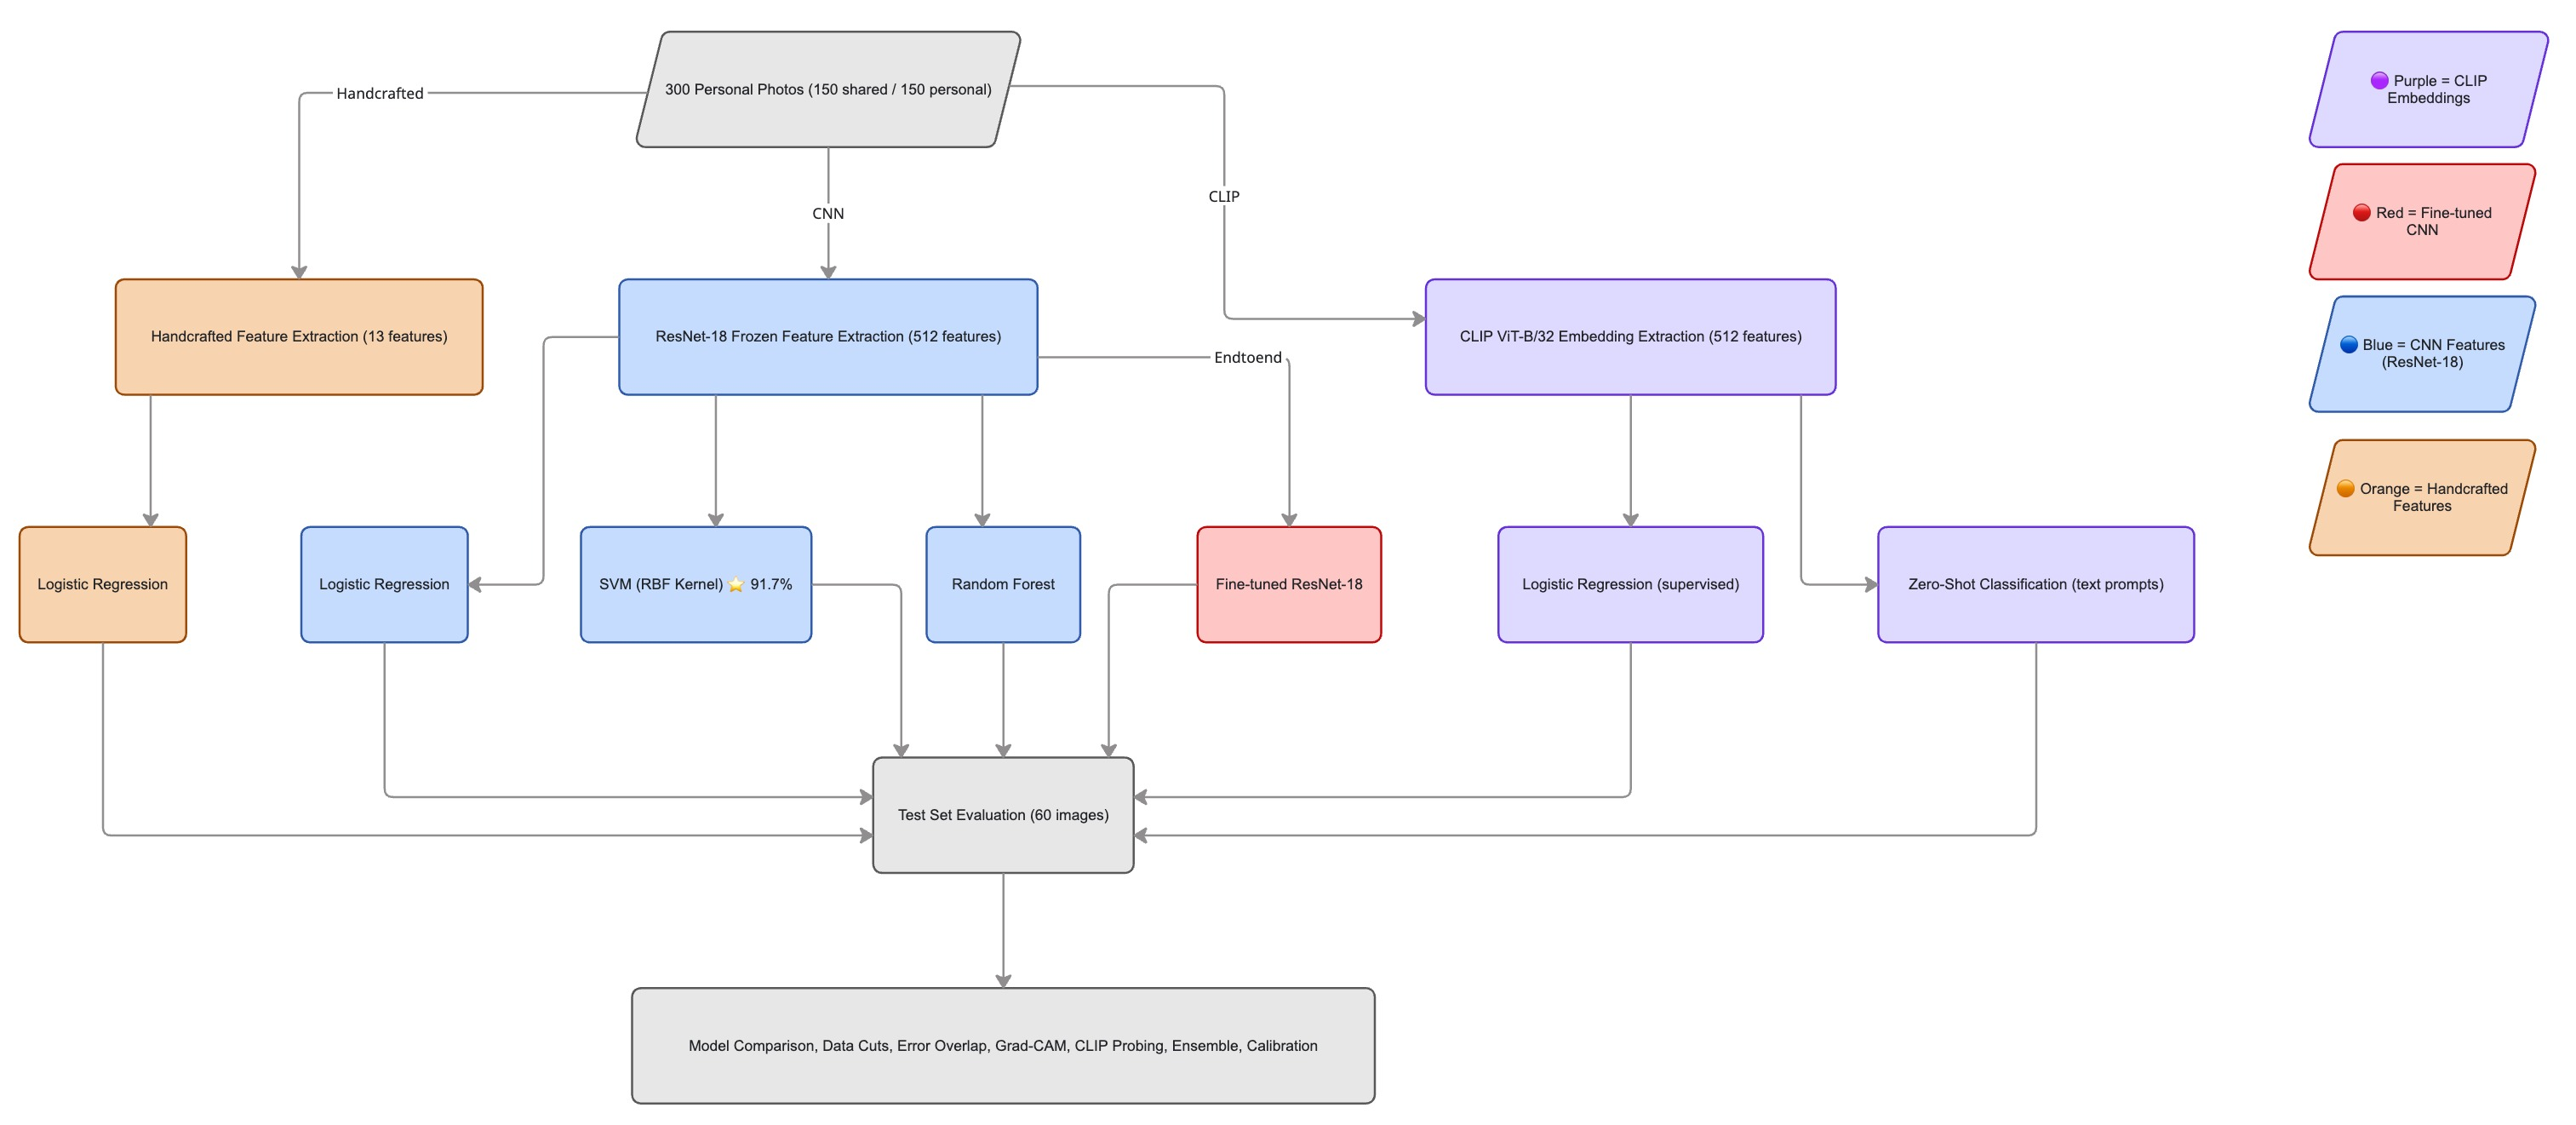

In [ ]:
# ─── Iteration I vs Iteration II comparison table ────────────────────────────
comparison = pd.DataFrame([
    {'': 'Iteration I Best', 'Model': 'LR on Handcrafted',
     'Features': '13 handcrafted', 'Test Accuracy': 0.800,
     'AUC': 0.851, 'Notes': 'Baseline'},
    {'': 'Iteration I CLIP', 'Model': 'CLIP + LR',
     'Features': '512 CLIP', 'Test Accuracy': 0.817,
     'AUC': 0.918, 'Notes': 'Extension'},
])

# Add best Iteration II model
if len(all_results) > 0:
    best_name = max(all_results.keys(), key=lambda k: all_results[k]['accuracy'])
    comparison = pd.concat([comparison, pd.DataFrame([{
        '': 'Iteration II Best',
        'Model': best_name,
        'Features': 'See above',
        'Test Accuracy': all_results[best_name]['accuracy'],
        'AUC': all_results[best_name]['auc'],
        'Notes': 'New'
    }])], ignore_index=True)

print("=" * 80)
print("ASSIGNMENT 1 vs ASSIGNMENT 2 COMPARISON")
print("=" * 80)
print(comparison.to_string(index=False))

ITERATION I vs ITERATION II COMPARISON
                              Model       Features  Test Accuracy      AUC     Notes
 Iteration I Best LR on Handcrafted 13 handcrafted       0.800000 0.851000  Baseline
 Iteration I CLIP         CLIP + LR       512 CLIP       0.817000 0.918000 Extension
Iteration II Best         CLIP + LR      See above       0.883333 0.945556       New


Despite achieving 91.7% validation accuracy during training, the fine-tuned CNN generalizes to only 83.3% on the test set, reflecting overfitting on the small 192-image training set.

### Key Findings


1.   **Representation quality matters, but classifier choice matters just as much.** The jump from handcrafted to CNN features improved LR accuracy by only 1.7 points (80.0% to 81.7%), but pairing CNN features with an RBF SVM jumped accuracy by 11.7 points (80.0% to 91.7%). The discriminative information was present in the CNN features all along; it took a nonlinear classifier to unlock it.
2.   **CLIP zero-shot classification works surprisingly well.** Without seeing a single labeled example, CLIP achieved 86.7% test accuracy using only text prompts. This means my sharing aesthetic has enough overlap with CLIP's pretrained understanding of "moody" vs "casual" photography that natural language descriptions alone can predict my behavior.
3.   **The remaining errors are likely label noise.** The SVM's 5 test errors are all shared by at least one other CNN-based model, and the "all models wrong" case study shows photos that look personal but were shared for non-visual reasons. This suggests the accuracy ceiling for any visual classifier on this dataset is around 90 to 95%, bounded by the inconsistency in my own labeling.
2.   **Different representations fail on different images.** The low misclassification overlap between handcrafted and CNN models (17% of handcrafted errors are also SVM errors) confirms these representations encode genuinely different information. The ensemble result (86.7% from three weak models combined) validates this complementarity.





### Limitations

Several limitations temper these results. The dataset remains small at 300 images, and the test set of 60 images means each percentage point of accuracy corresponds to 0.6 images, so differences smaller than about 3 to 4 points are not statistically reliable. The SVM's 91.7% (55/60 correct) is meaningfully better than the baseline's 80.0% (48/60 correct), but the 5-point gaps between mid-table models should be interpreted cautiously.

Label subjectivity remains a fundamental constraint. My sharing decisions are not perfectly consistent over time, and borderline photos may have been labeled differently on a different day. The "all models wrong" case study in Section 8.8 illustrates this directly.

The pretrained models carry biases from their training data. ResNet-18's ImageNet training emphasizes object categories, not aesthetic qualities. CLIP's internet-scale training reflects a particular culture's notion of visual appeal. These biases are embedded in the feature representations and cannot be fully removed by downstream classifiers.

Finally, the SVM hyperparameter search used a relatively coarse grid. A finer search over C and gamma, or the use of more advanced kernel methods, could potentially improve performance further.

### Future Directions

- **Larger dataset**: The learning curve analysis suggests more data would help. 500+ labeled images could push accuracy meaningfully higher.
- **Temporal analysis**: Has my aesthetic changed over time? Training on photos from different years could reveal evolving preferences.
- **Multi-label classification**: Instead of binary shared/not-shared, classify photos by type (landscape, portrait, food, urban) and predict which types get shared.
- **CLIP fine-tuning**: With a larger dataset, fine-tuning CLIP's image encoder (not just training a classifier on frozen embeddings) could produce a model specifically tuned to my visual preferences.

## Section 11: References

**Machine Learning Foundations:**
- Pedregosa, F. et al. (2011). [Scikit-learn: Machine Learning in Python.](https://jmlr.org/papers/v12/pedregosa11a.html) *Journal of Machine Learning Research*, 12, pp. 2825–2830.
- Bishop, C.M. (2006). [*Pattern Recognition and Machine Learning*.](https://link.springer.com/book/9780387310732) Springer.
- James, G., Witten, D., Hastie, T. and Tibshirani, R. (2021). [*An Introduction to Statistical Learning* (2nd ed.).](https://www.statlearning.com/) Springer.
- Murphy, K.P. (2022). [*Probabilistic Machine Learning: An Introduction*.](https://github.com/probml/pml-book/releases/latest/download/book1.pdf) MIT Press.

**Convolutional Neural Networks:**
- He, K., Zhang, X., Ren, S. and Sun, J. (2016). [Deep Residual Learning for Image Recognition.](https://arxiv.org/abs/1512.03385) *CVPR 2016*.
- Selvaraju, R.R. et al. (2017). [Grad-CAM: Visual Explanations from Deep Networks.](https://arxiv.org/abs/1610.02391) *ICCV 2017*.
- Dosovitskiy, A. et al. (2020). [An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale.](https://arxiv.org/abs/2010.11929) *ICLR 2021*.

**CLIP and Vision‑Language Models:**
- Radford, A. et al. (2021). [Learning Transferable Visual Models From Natural Language Supervision.](https://arxiv.org/abs/2103.00020) *ICML 2021*.
- Vaswani, A. et al. (2017). [Attention is All You Need.](https://arxiv.org/abs/1706.03762) *NeurIPS 2017*.

**Support Vector Machines:**
- Cortes, C. and Vapnik, V. (1995). [Support‑vector networks.](https://link.springer.com/article/10.1007/BF00994018) *Machine Learning*, 20(3), pp. 273–297.
- Schölkopf, B. and Smola, A.J. (2002). [*Learning with Kernels*.](https://mitpress.mit.edu/9780262536578/learning-with-kernels/) MIT Press.

**Random Forests:**
- Breiman, L. (2001). [Random Forests.](https://link.springer.com/article/10.1023/A:1010933404324) *Machine Learning*, 45(1), pp. 5–32.

**Optimization:**
- Kingma, D.P. and Ba, J. (2015). [Adam: A Method for Stochastic Optimization.](https://arxiv.org/abs/1412.6980) *ICLR 2015*.

**Feature Extraction:**
- Hasler, D. and Süsstrunk, S. (2003). [Measuring colourfulness in natural images.](https://doi.org/10.1117/12.477378) *SPIE Human Vision and Electronic Imaging*, 5007, pp. 87–95.
- Viola, P. and Jones, M. (2001). [Rapid object detection using a boosted cascade of simple features.](https://ieeexplore.ieee.org/document/990517) *CVPR 2001*.
- van der Maaten, L. and Hinton, G. (2008). [Visualizing Data using t‑SNE.](https://www.jmlr.org/papers/v9/vandermaaten08a.html) *JMLR*, 9, pp. 2579–2605.

**Other:**
- Cohen, J. (1988). [*Statistical Power Analysis for the Behavioral Sciences* (2nd ed.).](https://www.routledge.com/Statistical-Power-Analysis-for-the-Behavioral-Sciences/Cohen/p/book/9780805802832) Lawrence Erlbaum Associates.
- Murphy, K.P. (2023). [*Probabilistic Machine Learning: Advanced Topics*.](https://mitpress.mit.edu/9780262048439/probabilistic-machine-learning/) MIT Press.
- OpenCV. [Haar‑cascade classifier documentation](https://docs.opencv.org/4.x/db/d28/tutorial_cascade_classifier.html) and [pretrained XML files](https://github.com/opencv/opencv/tree/master/data/haarcascades).
- OpenAI. [CLIP GitHub repository](https://github.com/openai/CLIP).

## Section 12: AI Statement

I used ChatGPT and Claude throughout this project as learning tools. Primarily, I used them to deepen my understanding of concepts I was studying, particularly around SVM kernel theory, CNN transfer learning, and CLIP's contrastive training objective. When I encountered topics that the lecture material introduced but did not fully develop (such as the dual formulation of SVMs or the mechanics of Grad-CAM), I used these tools to find additional resources, alternative explanations, and relevant papers that helped me build a stronger conceptual foundation. I also used them to explore what other researchers have done with personal image classification and aesthetic prediction, which informed my choice of models and evaluation strategies. The code, analysis, and writing in this notebook are my own, built on the concepts and techniques I was working through at the time.